In [7]:
import os
import sys
import json
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
from matplotlib.ticker import ScalarFormatter, MultipleLocator
import seaborn as sns

from obspy import UTCDateTime, Stream, read
from tqdm import tqdm

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import ttest_ind_from_stats
import scipy.stats as stats

sys.path.append('..')

from functions.data_processing.read_data import load_seismic_data, load_label, load_seismic_data_test, load_data

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'legend.fontsize': 6,
    'figure.figsize': (5.5, 3.5),
    'axes.formatter.limits': (-3, 6),
    'axes.formatter.use_mathtext': True,
})
sns.set_context('notebook', font_scale=1)



In [2]:
import json
with open("../config/event_id_map.json", "r") as f:
    event_id_map = json.load(f)

In [3]:
def plot_grouped_bar_with_error(data, x, y, hue, hue_order, ax,
                                palette="viridis", bar_width=0.35, ylim=None):
    """
    Plot grouped bar chart with mean and standard error using Matplotlib.

    Parameters:
    - data: pd.DataFrame
    - x: str, column for x-axis categories (e.g., "Interval")
    - y: str, column for y-axis values (e.g., "MSE_ts")
    - hue: str, column to split bars within each x (e.g., "Model")
    - hue_order: list of str, order of hue categories (e.g., ["LSTM", "xLSTM"])
    - ax: matplotlib.axes.Axes, axis to draw the plot on
    - palette: str or colormap, default "viridis"
    - bar_width: float, width of each bar
    """

    # Group data and compute mean and SE
    summary_df = data.groupby([x, hue]).agg(
        mean_y=(y, 'mean'),
        se_y=(y, lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    ).reset_index()

    x_labels = summary_df[x].unique()
    x_pos = np.arange(len(x_labels))
    cmap = ['yellowgreen', 'turquoise', 'indianred', "grey"]

    for i, hue_val in enumerate(hue_order):
        subset = summary_df[summary_df[hue] == hue_val]
        offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
        xpos = x_pos + offset

        bars = ax.bar(
            xpos,
            subset['mean_y'],
            yerr=subset['se_y'],
            width=bar_width,
            label=hue_val,
            color=cmap[i],
            capsize=5,
            edgecolor='black'
        )

        # Annotate bars with height
        for j, bar in enumerate(bars):
            height = bar.get_height()
            err = float(subset['se_y'].iloc[j])
            y_point = height + err  # place annotation at top of yerr
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, y_point),
                        xytext=(0, 3),
                        textcoords='offset points',
                        ha='center', va='bottom',
                        fontsize=6, fontweight='bold')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend(title=hue)
    if ylim is not None:
        ax.set_ylim(ylim)
    # ax.set_title(f"Mean {y} by {x} and {hue}")
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    return None    

# Combined Image of Inversion Results

In [71]:
event_map = event_id_map



In [72]:
base_dirs = {i: Path(f"../comparison_baseline_cv_5_15_{i}/average_60_45/") for i in range(1, 4)}
event_ids = ["1", "3", "4", "5", "6", "7", "8", "9"]
juldays = [
    event_map[i]["julday"] if isinstance(event_map[i]["julday"], int) else event_map[i]["julday"][0]
    for i in event_ids
]
interval = 5
config = "v5"
models = ["LSTM", "xLSTM"]


def load_best_prediction(base_dir, model, interval, config, julday, source_idx):
    best_comb = pd.read_csv(base_dir / "model_evaluation" / "best_combinations.csv")
    mask = (
        (best_comb["Interval"] == interval)
        & (best_comb["Config"] == config)
        & (best_comb["Model"] == model)
        & (best_comb["Test"] == julday)
    )
    best_row = best_comb.loc[mask].squeeze()
    filename = base_dir / "output_df" / config / str(interval) / f"{model}_t{int(best_row.Test)}_v{int(best_row.Val)}.csv"
    return (
        pd.read_csv(filename)[["Timestamps", "Predicted_Output"]]
        .rename(columns={"Predicted_Output": f"Predicted_Output_{source_idx}"})
    )


def load_combined_model_outputs(base_dirs, models, juldays, interval, config):
    combined = {model: {} for model in models}
    for model in models:
        for julday in juldays:
            dfs = [
                load_best_prediction(Path(base_dir), model, interval, config, julday, idx)
                for idx, base_dir in base_dirs.items()
            ]
            merged_df = dfs[0]
            for df in dfs[1:]:
                merged_df = merged_df.merge(df, on="Timestamps", how="left")
            preds = merged_df.filter(like="Predicted_Output_")
            merged_df["Mean_PO"] = preds.mean(axis=1)
            merged_df["Std_PO"] = preds.std(axis=1)
            combined[model][julday] = merged_df
    return combined


dfcomp = load_combined_model_outputs(base_dirs, models, juldays, interval, config)


In [104]:
def mpl_dates_from_series(series):
    return series.apply(lambda x: UTCDateTime(x).matplotlib_date).to_numpy()


def configure_axis(ax, y_label, y_lim, major, minor):
    if y_lim is not None:
        ax.set_ylim(*y_lim)
    ax.set_ylabel(y_label, fontweight="bold", fontsize=12)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_locator(MultipleLocator(major))
    ax.yaxis.set_minor_locator(MultipleLocator(minor))
    ax.tick_params(axis="both", which="major", labelsize=12, length=3)
    ax.tick_params(axis="y", which="minor", labelsize=12, length=3)
    ax.grid(axis="y", color="grey", linestyle="--", lw=0.5, alpha=0.5, zorder=0)


def plot_combined_results(event_ids, juldays, dfcomp, interval, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    style_map = {
        "xLSTM": {"mean_color": "red", "fill_color": "green", "fill_alpha": 0.5},
        "LSTM": {"mean_color": "blue", "fill_color": "turquoise", "fill_alpha": 0.3},
    }

    for julday, event_id in zip(juldays, event_ids):
        fig, axes = plt.subplots(2, 1, figsize=(5.5, 5.5), sharex=True)
        seismic = load_seismic_data(event_id, "ILL11", 2019)
        label = load_label([event_id], "ILL11", interval, "average", trim=True, smoothing=None, divide_by=None)
        label_s = load_label([event_id], "ILL11", interval, "average", trim=True, smoothing=60, divide_by=None)

        times = seismic[0].times("matplotlib")
        axes[0].plot(times, seismic[0].data, color="black", linewidth=1, alpha=0.75, label="ILL11 Seismic Input")
        axes[0].set_xlim(times[0], times[-1])
        axes[0].xaxis_date()
        axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
        configure_axis(axes[0], "Amplitude [mm/s]", (-1.6, 1.6), 0.5, 0.1)
        axes[0].legend(loc="upper right")

        label_times = mpl_dates_from_series(label.Timestamp)
        label_s_times = mpl_dates_from_series(label_s.Timestamp)
        axes[1].plot(label_times, label["Fv [kN]"], color="black", alpha=0.5, linewidth=2, label="Measured IF Data", zorder=0)
        axes[1].plot(label_s_times, label_s["Fv [kN]"], color="black", alpha=1.0, linewidth=2, label="Smoothed IF Data", zorder=0)

        for model in models:
            temp = dfcomp[model][julday]
            times = mpl_dates_from_series(temp["Timestamps"])
            mean = temp["Mean_PO"].to_numpy()
            std = temp["Std_PO"].to_numpy()
            props = style_map[model]
            axes[1].plot(times, mean, color=props["mean_color"], linewidth=2, label=f"{model} Model Output", zorder=1)
            axes[1].fill_between(times, mean - std, mean + std, color=props["fill_color"], alpha=props["fill_alpha"], linewidth=0, label=f"{model} Std. Model Output", zorder=0)

        configure_axis(axes[1], "Impact Force [kN]", (-0.2, 40), 5, 2.5)
        axes[1].set_xlabel("Time [UTC+0]", fontweight="bold", fontsize=12)
        axes[1].legend(loc="upper right")
        axes[0].set_title(f"Date: {UTCDateTime(year=2019, julday=julday).strftime('%Y-%m-%d')}", fontsize=12, fontweight='bold')

        fig.tight_layout()
        fig.savefig(output_dir / f"{julday}.png", dpi=600)
        plt.close(fig)


In [180]:
plot_combined_results(event_ids, juldays, dfcomp, interval, "./output_images4/training_output_wlstm")


In [9]:
base_dir = "../model_test/ILL11"

In [14]:
years = [2020] * 7
juldays = [156, 159, 160, 169, 181, 229, 243]
start_times = ["2020-06-04T15:00:00", "2020-06-07T08:00:00",\
    "2020-06-08T15:00:00",
    "2020-06-17T04:00:00",
    "2020-06-29T05:00:00",
    "2020-08-16T22:00:00",
    "2020-08-30T05:00:00"]
end_times = ["2020-06-04T18:00:00", "2020-06-07T11:00:00",\
    "2020-06-08T20:00:00",
    "2020-06-17T07:00:00",
    "2020-06-29T07:30:00",
    "2020-08-16T23:59:59",
    "2020-08-30T12:00:00"]
station = "ILL11"

# fig, ax = plt.subplots(7, 1, sharey = True, figsize=(7.5,11.5))
for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    fig, ax = plt.subplots(2, 1, figsize=(5.5, 5.5), sharex=True);
    st = load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
    df1 = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday}.csv")
    df2 = pd.read_csv(f"{base_dir}/LSTM_{interval}/{year}/df/{julday}.csv")
    st.trim(starttime=UTCDateTime(start_time), endtime=UTCDateTime(end_time))
    df1 = df1[df1.Timestamps.between(start_time, end_time)]
    df2 = df2[df2.Timestamps.between(start_time, end_time)]
    # if i == 0:
    #     break
    # else:
    #     continue
    d1 = ax[0].plot(st[0].times('matplotlib'), st[0].data, color="black", linewidth=1, alpha=0.75, label="ILL11 Seismic Input")
    ax[0].set_xlim(st[0].times('matplotlib')[0], st[0].times('matplotlib')[-1])
    ax[0].xaxis_date()
    ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax[0].set_ylim(-1.1, 1.1);

    # ax[1] = ax.twinx()
    d2 = ax[1].plot([UTCDateTime(i).matplotlib_date for i in df1.Timestamps], df1.Predicted_Output_Mean, color='red', alpha=0.9, linewidth=2, label='xLSTM Model Output', zorder=1)
    ax[1].fill_between([UTCDateTime(i).matplotlib_date for i in df1.Timestamps],
                      df1.Predicted_Output_Min,
                      df1.Predicted_Output_Max,
                      color='maroon',
                      alpha=0.3,
                      linewidth=0,
                      zorder=0)
    # d3 = ax[1].plot([UTCDateTime(i).matplotlib_date for i in df2.Timestamps], df2.Predicted_Output_Mean, color='blue', linewidth=1, label='LSTM Model Output', zorder=1)
    # ax[1].fill_between([UTCDateTime(i).matplotlib_date for i in df2.Timestamps],
    #                   df2.Predicted_Output_Min,
    #                   df2.Predicted_Output_Max,
    #                   color='turquoise',
    #                   alpha=0.5,
    #                   linewidth=0,
    #                   zorder=0)
    ax[1].set_ylim(-0.2, 40);
    ax[1].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax[1].yaxis.set_major_locator(MultipleLocator(10))
    ax[1].yaxis.set_minor_locator(MultipleLocator(5))
    ax[1].tick_params(axis='y', which='major', labelsize=10, length=3)
    ax[1].tick_params(axis='y', which='minor', labelsize=10, length=3)
    ax[1].set_xlabel(f"Time [UTC+0]", fontweight='bold', fontsize=10)
    ax[0].set_ylabel("Amplitude [mm/s]", fontweight='bold', fontsize=10)
    ax[1].set_ylabel("Impact Force [kN]", fontweight='bold', fontsize=10)
    lns = d1
    labs = [l.get_label() for l in lns]
    ax[0].legend(lns, labs, loc='upper right')
    lns = d2
    labs = [l.get_label() for l in lns]
    ax[1].legend(lns, labs, loc='upper right')
    ax[0].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax[0].yaxis.set_major_locator(MultipleLocator(1))
    ax[0].yaxis.set_minor_locator(MultipleLocator(0.5))
    ax[0].tick_params(axis='both', which='major', labelsize=10, length=3)
    ax[0].tick_params(axis='y', which='minor', labelsize=10, length=3)
    ax[0].set_title(f"Date: {UTCDateTime(year=2020, julday=julday).strftime("%Y-%m-%d")}", fontsize=10, fontweight="bold")

    fig.tight_layout()
    fig.savefig(f"./output_images4/testing_output/2020_{julday}.png", dpi=600)
    plt.close(fig=fig)
    # break

In [24]:
# fig, ax = plt.subplots()
# bin_heights, bin_widths, _ = ax.hist(df["Predicted_Output_Mean"], bins=np.arange(3,46,2), rwidth=0.97, density=False, alpha=0.8, color="red", log=False, label="Target")

In [25]:
# print(bin_widths[(bin_widths >= 15) & (bin_widths <= 25)])
# print(bin_heights[(bin_widths[:-1] >= 15) & (bin_widths[:-1] <= 25)])
# print(len(df[df['Predicted_Output_Mean'] > 3]))
# sum1 = np.sum(bin_heights[(bin_widths[:-1] > 15) & (bin_widths[:-1] <= 25)])
# print(sum1/len(df[df['Predicted_Output_Mean'] > 3]))

In [22]:
years = [2021] * 11
juldays = [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]
start_times = ["2021-05-11 13:30:00", "2021-05-16 15:30:00", "2021-05-21 22:30:00", "2021-06-05 09:00:00",
            "2021-06-22 19:30:00", "2021-06-24 14:30:00", "2021-07-06 18:30:00", "2021-07-13 15:00:00",
            "2021-07-16 03:00:00", "2021-08-07 14:00:00", "2021-09-19 05:30:00"]
start_times = [UTCDateTime(x) for x in start_times]
end_times = ["2021-05-11 17:00:00", "2021-05-16 20:00:00", "2021-05-22 02:00:00", "2021-06-05 13:00:00",
            "2021-06-22 22:30:00", "2021-06-24 17:30:00", "2021-07-06 21:00:00", "2021-07-13 20:00:00",
            "2021-07-16 08:00:00", "2021-08-07 17:30:00", "2021-09-19 12:30:00"]
end_times = [UTCDateTime(x) for x in end_times]
station = "ILL11"

# for idx, j in enumerate([5, 6]):
#     fig, ax = plt.subplots(len(years[idx*j:(idx+1)*(j+1)]), 1, sharey = True, figsize=(7.5,8.5))
#     for i, (year, julday, start_time, end_time) in enumerate(zip(years[idx*j:(idx+1)*(j+1)], juldays[idx*j:(idx+1)*(j+1)], start_times[idx*j:(idx+1)*(j+1)], end_times[idx*j:(idx+1)*(j+1)])):
for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    if julday == 142:
        st = Stream()
        st += load_seismic_data_test(julday=julday-1, station=station, year=year, component="EHZ", network="9S")
        st += load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
        st.merge(method=1, fill_value='latest', interpolation_samples=0)
        dfa = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday-1}.csv", index_col=False)
        dfb = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday}.csv", index_col=False)
        df1 = pd.concat([dfa, dfb], ignore_index=True)
        dfa = pd.read_csv(f"{base_dir}/LSTM_{interval}/{year}/df/{julday-1}.csv", index_col=False)
        dfb = pd.read_csv(f"{base_dir}/LSTM_{interval}/{year}/df/{julday}.csv", index_col=False)
        df2 = pd.concat([dfa, dfb], ignore_index=True)
    else:
        st = load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
        df1 = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday}.csv")
        df2 = pd.read_csv(f"{base_dir}/LSTM_{interval}/{year}/df/{julday}.csv")
        
    fig, ax = plt.subplots(2, 1, figsize=(5.5, 5.5), sharex=True);
    st.trim(starttime=UTCDateTime(start_time), endtime=UTCDateTime(end_time))
    df1 = df1[df1.Timestamps.between(start_time, end_time)]
    df2 = df2[df2.Timestamps.between(start_time, end_time)]
    # if i == 0:
    #     break
    # else:
    #     continue
    d1 = ax[0].plot(st[0].times('matplotlib'), st[0].data, color="black", linewidth=1, alpha=0.75, label="ILL11 Seismic Input")
    ax[0].set_xlim(st[0].times('matplotlib')[0], st[0].times('matplotlib')[-1])
    ax[0].xaxis_date()
    ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax[0].set_ylim(-1.1, 1.1);

    # ax[1] = ax.twinx()
    d2 = ax[1].plot([UTCDateTime(i).matplotlib_date for i in df1.Timestamps], df1.Predicted_Output_Mean, alpha=0.9, color='red', linewidth=2, label='xLSTM Model Output', zorder=1)
    ax[1].fill_between([UTCDateTime(i).matplotlib_date for i in df1.Timestamps],
                      df1.Predicted_Output_Min,
                      df1.Predicted_Output_Max,
                      color='maroon',
                      alpha=0.3,
                      linewidth=0,
                      zorder=0)
    # d3 = ax[1].plot([UTCDateTime(i).matplotlib_date for i in df2.Timestamps], df2.Predicted_Output_Mean, color='blue', linewidth=1, label='LSTM Model Output', zorder=1)
    # ax[1].fill_between([UTCDateTime(i).matplotlib_date for i in df2.Timestamps],
    #                   df2.Predicted_Output_Min,
    #                   df2.Predicted_Output_Max,
    #                   color='turquoise',
    #                   alpha=0.5,
    #                   linewidth=0,
    #                   zorder=0)
    ax[1].set_ylim(-0.2, 40);
    ax[1].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax[1].yaxis.set_major_locator(MultipleLocator(10))
    ax[1].yaxis.set_minor_locator(MultipleLocator(5))
    ax[1].tick_params(axis='y', which='major', labelsize=10, length=3)
    ax[1].tick_params(axis='y', which='minor', labelsize=10, length=3)
    ax[1].set_xlabel(f"Time [UTC+0]", fontweight='bold', fontsize=10)
    ax[0].set_ylabel("Amplitude [mm/s]", fontweight='bold', fontsize=10)
    ax[1].set_ylabel("Impact Force [kN]", fontweight='bold', fontsize=10)
    lns = d1
    labs = [l.get_label() for l in lns]
    ax[0].legend(lns, labs, loc='upper right')
    lns = d2
    labs = [l.get_label() for l in lns]
    ax[1].legend(lns, labs, loc='upper right')
    ax[0].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax[0].yaxis.set_major_locator(MultipleLocator(1))
    ax[0].yaxis.set_minor_locator(MultipleLocator(0.5))
    ax[0].tick_params(axis='both', which='major', labelsize=10, length=3)
    ax[0].tick_params(axis='y', which='minor', labelsize=10, length=3)
    ax[0].set_title(f"Date: {UTCDateTime(year=2021, julday=julday).strftime("%Y-%m-%d")}", fontsize=10, fontweight="bold")

    fig.savefig(f"./output_images4/testing_output/2021_{julday}.png", dpi=600)
    plt.close(fig=fig)

In [23]:
# fig, ax = plt.subplots()
# bin_heights, bin_widths, _ = ax.hist(df["Predicted_Output_Mean"], bins=np.arange(3,46,2), rwidth=0.97, density=False, alpha=0.8, color="red", log=False, label="Target")

In [24]:
# print(bin_widths[(bin_widths >= 15) & (bin_widths <= 25)])
# print(bin_heights[(bin_widths[:-1] >= 15) & (bin_widths[:-1] <= 25)])
# print(len(df[df['Predicted_Output_Mean'] > 3]))
# sum1 = np.sum(bin_heights[(bin_widths[:-1] > 15) & (bin_widths[:-1] <= 25)])
# print(sum1/len(df[df['Predicted_Output_Mean'] > 3]))

In [25]:
years = [2022] * 2
juldays = [156, 185]
start_times = ["2022-06-05 10:30:00", "2022-07-04 21:00:00"]
start_times = [UTCDateTime(x) for x in start_times]
end_times = ["2022-06-05 13:30:00", "2022-07-04 23:59:59"]
end_times = [UTCDateTime(x) for x in end_times]
station = "ILL11"

# fig, ax = plt.subplots(2, 1, sharey = True, figsize=(7.5,3.5))
for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    fig, ax = plt.subplots(2, 1, figsize=(5.5, 5.5), sharex=True);
    st = load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
    df1 = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday}.csv")
    df2 = pd.read_csv(f"{base_dir}/LSTM_{interval}/{year}/df/{julday}.csv")
    st.trim(starttime=UTCDateTime(start_time), endtime=UTCDateTime(end_time))
    df1 = df1[df1.Timestamps.between(start_time, end_time)]
    df2 = df2[df2.Timestamps.between(start_time, end_time)]
    # if i == 0:
    #     break
    # else:
    #     continue
    d1 = ax[0].plot(st[0].times('matplotlib'), st[0].data, color="black", linewidth=1, alpha=0.75, label="ILL11 Seismic Input")
    ax[0].set_xlim(st[0].times('matplotlib')[0], st[0].times('matplotlib')[-1])
    ax[0].xaxis_date()
    ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax[0].set_ylim(-1.1, 1.1);

    # ax[1] = ax.twinx()
    d2 = ax[1].plot([UTCDateTime(i).matplotlib_date for i in df1.Timestamps], df1.Predicted_Output_Mean, alpha=0.9, color='red', linewidth=2, label='xLSTM Model Output', zorder=1)
    ax[1].fill_between([UTCDateTime(i).matplotlib_date for i in df1.Timestamps],
                      df1.Predicted_Output_Min,
                      df1.Predicted_Output_Max,
                      color='maroon',
                      alpha=0.3,
                      linewidth=0,
                      zorder=0)
    # d3 = ax[1].plot([UTCDateTime(i).matplotlib_date for i in df2.Timestamps], df2.Predicted_Output_Mean, color='blue', linewidth=1, label='LSTM Model Output', zorder=1)
    # ax[1].fill_between([UTCDateTime(i).matplotlib_date for i in df2.Timestamps],
    #                   df2.Predicted_Output_Min,
    #                   df2.Predicted_Output_Max,
    #                   color='turquoise',
    #                   alpha=0.5,
    #                   linewidth=0,
    #                   zorder=0)
    ax[1].set_ylim(-0.2, 40);
    ax[1].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax[1].yaxis.set_major_locator(MultipleLocator(10))
    ax[1].yaxis.set_minor_locator(MultipleLocator(5))
    ax[1].tick_params(axis='y', which='major', labelsize=10, length=3)
    ax[1].tick_params(axis='y', which='minor', labelsize=10, length=3)
    ax[1].set_xlabel(f"Time [UTC+0]", fontweight='bold', fontsize=10)
    ax[0].set_ylabel("Amplitude [mm/s]", fontweight='bold', fontsize=10)
    ax[1].set_ylabel("Impact Force [kN]", fontweight='bold', fontsize=10)
    lns = d1
    labs = [l.get_label() for l in lns]
    ax[0].legend(lns, labs, loc='upper right')
    lns = d2
    labs = [l.get_label() for l in lns]
    ax[1].legend(lns, labs, loc='upper right')
    ax[0].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax[0].yaxis.set_major_locator(MultipleLocator(1))
    ax[0].yaxis.set_minor_locator(MultipleLocator(0.5))
    ax[0].tick_params(axis='both', which='major', labelsize=10, length=3)
    ax[0].tick_params(axis='y', which='minor', labelsize=10, length=3)
    ax[0].set_title(f"Date: {UTCDateTime(year=2022, julday=julday).strftime("%Y-%m-%d")}", fontsize=10, fontweight="bold")

    fig.tight_layout()
    fig.savefig(f"./output_images4/testing_output/2022_{julday}.png", dpi=600)
    plt.close(fig=fig)

In [26]:
# fig, ax = plt.subplots()
# bin_heights, bin_widths, _ = ax.hist(df["Predicted_Output_Max"], bins=np.arange(3,46,2), rwidth=0.97, density=False, alpha=0.8, color="red", log=False, label="Target")

In [27]:
# print(bin_widths[(bin_widths >= 25) & (bin_widths <= 35)])
# print(bin_heights[(bin_widths[:-1] >= 15) & (bin_widths[:-1] <= 25)])
# print(len(df[df['Predicted_Output_Mean'] > 3]))
# sum1 = np.sum(bin_heights[(bin_widths[:-1] > 15) & (bin_widths[:-1] <= 25)])
# print(sum1/len(df[df['Predicted_Output_Mean'] > 3]))

In [28]:
years = [2023] * 3
juldays = [153, 161, 193]
start_times = ["2023-06-02 17:00:00", "2023-06-10 05:00:00", "2023-07-12 03:00:00"]
start_times = [UTCDateTime(x) for x in start_times]
end_times = ["2023-06-02 21:00:00", "2023-06-10 09:00:00", "2023-07-12 06:00:00"]
end_times = [UTCDateTime(x) for x in end_times]
station = "ILL11"

for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    fig, ax = plt.subplots(2, 1, figsize=(5.5, 5.5), sharex=True);
    st = load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
    df1 = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday}.csv")
    df2 = pd.read_csv(f"{base_dir}/LSTM_{interval}/{year}/df/{julday}.csv")
    st.trim(starttime=UTCDateTime(start_time), endtime=UTCDateTime(end_time))
    df1 = df1[df1.Timestamps.between(start_time, end_time)]
    df2 = df2[df2.Timestamps.between(start_time, end_time)]
    # if i == 0:
    #     break
    # else:
    #     continue
    d1 = ax[0].plot(st[0].times('matplotlib'), st[0].data, color="black", linewidth=1, alpha=0.75, label="ILL11 Seismic Input")
    ax[0].set_xlim(st[0].times('matplotlib')[0], st[0].times('matplotlib')[-1])
    ax[0].xaxis_date()
    ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax[0].set_ylim(-1.1, 1.1);

    # ax[1] = ax.twinx()
    d2 = ax[1].plot([UTCDateTime(i).matplotlib_date for i in df1.Timestamps], df1.Predicted_Output_Mean, alpha=0.9, color='red', linewidth=2, label='xLSTM Model Output', zorder=1)
    ax[1].fill_between([UTCDateTime(i).matplotlib_date for i in df1.Timestamps],
                      df1.Predicted_Output_Min,
                      df1.Predicted_Output_Max,
                      color='maroon',
                      alpha=0.3,
                      linewidth=0,
                      zorder=0)
    # d3 = ax[1].plot([UTCDateTime(i).matplotlib_date for i in df2.Timestamps], df2.Predicted_Output_Mean, color='blue', linewidth=1, label='LSTM Model Output', zorder=1)
    # ax[1].fill_between([UTCDateTime(i).matplotlib_date for i in df2.Timestamps],
    #                   df2.Predicted_Output_Min,
    #                   df2.Predicted_Output_Max,
    #                   color='turquoise',
    #                   alpha=0.5,
    #                   linewidth=0,
    #                   zorder=0)
    ax[1].set_ylim(-0.2, 40);
    ax[1].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax[1].yaxis.set_major_locator(MultipleLocator(10))
    ax[1].yaxis.set_minor_locator(MultipleLocator(5))
    ax[1].tick_params(axis='y', which='major', labelsize=10, length=3)
    ax[1].tick_params(axis='y', which='minor', labelsize=10, length=3)
    ax[1].set_xlabel(f"Time [UTC+0]", fontweight='bold', fontsize=10)
    ax[0].set_ylabel("Amplitude [mm/s]", fontweight='bold', fontsize=10)
    ax[1].set_ylabel("Impact Force [kN]", fontweight='bold', fontsize=10)
    lns = d1
    labs = [l.get_label() for l in lns]
    ax[0].legend(lns, labs, loc='upper right')
    lns = d2
    labs = [l.get_label() for l in lns]
    ax[1].legend(lns, labs, loc='upper right')
    ax[0].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax[0].yaxis.set_major_locator(MultipleLocator(1))
    ax[0].yaxis.set_minor_locator(MultipleLocator(0.5))
    ax[0].tick_params(axis='both', which='major', labelsize=10, length=3)
    ax[0].tick_params(axis='y', which='minor', labelsize=10, length=3)
    ax[0].set_title(f"Date: {UTCDateTime(year=2023, julday=julday).strftime("%Y-%m-%d")}", fontsize=10, fontweight="bold")

    fig.tight_layout()
    fig.savefig(f"./output_images4/testing_output/2023_{julday}.png", dpi=600)
    plt.close(fig=fig)

In [44]:
# years = [2020] * 7
# juldays = [156, 159, 160, 169, 181, 229, 243]
# start_times = ["2020-06-04T15:00:00", "2020-06-07T08:00:00",\
#     "2020-06-08T15:00:00",
#     "2020-06-17T04:00:00",
#     "2020-06-29T05:00:00",
#     "2020-08-16T22:00:00",
#     "2020-08-30T05:00:00"]
# end_times = ["2020-06-04T18:00:00", "2020-06-07T11:00:00",\
#     "2020-06-08T20:00:00",
#     "2020-06-17T07:00:00",
#     "2020-06-29T07:30:00",
#     "2020-08-16T23:59:59",
#     "2020-08-30T12:00:00"]
# station = "ILL11"

# # fig, ax = plt.subplots(7, 1, sharey = True, figsize=(7.5,11.5))
# fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5))
# for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
#     st = load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
#     df = pd.read_csv(f"{base_dir}/{year}/df/{julday}.csv")
#     st.trim(starttime=UTCDateTime(start_time), endtime=UTCDateTime(end_time))
#     df = df[df.Timestamps.between(start_time, end_time)]
#     if i == 0:
#         bin_heights1, bin_widths1, _ = ax.hist(df.Predicted_Output_Mean, bins=np.arange(3,45,2), alpha=0.5, density=False)
#     else:
#         b, w, _ = ax.hist(df.Predicted_Output_Mean, bins=np.arange(3,45,2), alpha=0.5, density=False)
#         bin_heights1 += b

# years = [2021] * 11
# juldays = [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]
# start_times = ["2021-05-11 13:30:00", "2021-05-16 15:30:00", "2021-05-21 22:30:00", "2021-06-05 09:00:00",
#             "2021-06-22 19:30:00", "2021-06-24 14:30:00", "2021-07-06 18:30:00", "2021-07-13 15:00:00",
#             "2021-07-16 03:00:00", "2021-08-07 14:00:00", "2021-09-19 05:30:00"]
# start_times = [UTCDateTime(x) for x in start_times]
# end_times = ["2021-05-11 17:00:00", "2021-05-16 20:00:00", "2021-05-22 02:00:00", "2021-06-05 13:00:00",
#             "2021-06-22 22:30:00", "2021-06-24 17:30:00", "2021-07-06 21:00:00", "2021-07-13 20:00:00",
#             "2021-07-16 08:00:00", "2021-08-07 17:30:00", "2021-09-19 12:30:00"]
# end_times = [UTCDateTime(x) for x in end_times]
# station = "ILL11"

# # for idx, j in enumerate([5, 6]):
# #     fig, ax = plt.subplots(len(years[idx*j:(idx+1)*(j+1)]), 1, sharey = True, figsize=(7.5,8.5))
# #     for i, (year, julday, start_time, end_time) in enumerate(zip(years[idx*j:(idx+1)*(j+1)], juldays[idx*j:(idx+1)*(j+1)], start_times[idx*j:(idx+1)*(j+1)], end_times[idx*j:(idx+1)*(j+1)])):
# fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5))
# for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    
#     if julday == 142:
#         st = Stream()
#         st += load_seismic_data_test(julday=julday-1, station=station, year=year, component="EHZ", network="9S")
#         st += load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
#         st.merge(method=1, fill_value='latest', interpolation_samples=0)
#         df1 = pd.read_csv(f"{base_dir}/{year}/df/{julday-1}.csv", index_col=False)
#         df2 = pd.read_csv(f"{base_dir}/{year}/df/{julday}.csv", index_col=False)
#         df = pd.concat([df1, df2], ignore_index=True)
#     else:
#         st = load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
#         df = pd.read_csv(f"{base_dir}/{year}/df/{julday}.csv")
        
#     st.trim(starttime=UTCDateTime(start_time), endtime=UTCDateTime(end_time))
#     df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
#     df = df[df.Timestamps.between(start_time, end_time)]
#     if i == 0:
#         bin_heights2, bin_widths2, _ = ax.hist(df.Predicted_Output_Mean, bins=np.arange(3,45,2), alpha=0.5, density=False)
#     else:
#         b, w, _ = ax.hist(df.Predicted_Output_Mean, bins=np.arange(3,45,2), alpha=0.5, density=False)
#         bin_heights2 += b

# Distributions

In [41]:
from functions.data_processing.read_data import load_seismic_data, load_label, load_seismic_data_test

plt.rcParams.update( {'font.size':7,
                      'axes.formatter.limits': (-3, 6),
                      'axes.formatter.use_mathtext': True} )
import json
from matplotlib.ticker import ScalarFormatter, MultipleLocator

with open("../config/event_id_map.json", "r") as file:
    event_map = json.load(file)

In [43]:
base_dir = {i:f"../comparison_baseline_cv_5_15_{i}/average_60_45/" for i in range(1,4)}
base_dir
event_ids = ["1", "3", "4", "5", "6", "7", "8", "9"]
juldays = [event_map[i]['julday'] if type(event_map[i]['julday']) is int  else event_map[i]['julday'][0] for i in event_ids]
# globals()[f'dfcomp_{julday}']
interval = 5
config = 'v_larger'
model = "xLSTM"
for i in range(1, 4):
    best_comb = pd.read_csv(f"{base_dir[i]}/model_evaluation/best_combinations.csv")
    best_comb = best_comb[(best_comb['Interval'] == interval) & (best_comb['Config'] == config) & (best_comb['Model'] == model)]
    for julday in (juldays):
        best_comb_per = best_comb[best_comb['Test'] == julday]
        test = best_comb_per['Test'].item()
        val = best_comb_per['Val'].item()
        # print(test, val)
        df_filename = f"{base_dir[i]}/output_df/{config}/{interval}/{model}_t{test}_v{val}.csv"
        temp = pd.read_csv(df_filename)
        if i == 1:
            globals()[f"dfcomp_{julday}"] = temp
        else:
            globals()[f"dfcomp_{julday}"] = pd.merge(left=globals()[f"dfcomp_{julday}"],
                                                    right=temp[['Timestamps','Predicted_Output']],
                                                    on='Timestamps',
                                                    how='left',
                                                    )
            
for julday in juldays:
    globals()[f"dfcomp_{julday}"]['Mean_PO'] = globals()[f"dfcomp_{julday}"][['Predicted_Output_x', 'Predicted_Output_y', 'Predicted_Output']].mean(axis=1)
    globals()[f"dfcomp_{julday}"]['Std_PO'] = globals()[f"dfcomp_{julday}"][['Predicted_Output_x', 'Predicted_Output_y', 'Predicted_Output']].std(axis=1)

In [ ]:
labels = {i:load_label([i], "ILL11", 5, "average", trim = True, smoothing = None, divide_by = None) for i in ["1", "3", "4", "5", "6", "7", "8", "9"]}

In [45]:
def fit_and_plot_pl(ax, bin_heights, bin_edges, color):
    bin_widths = np.diff(bin_edges)
    bin_centers = bin_edges[:-1] + bin_widths / 2
    density = bin_heights / bin_widths
    mask = (density > 0) & (bin_centers > 0)
    xs = bin_centers[mask]
    ys = density[mask]
    # xs = xs[:-2]
    # ys = ys[:-2]
    # 1) simple log-log linear fit (fast, robust)
    log_a, log_b = np.polyfit(np.log10(xs), np.log10(ys), 1)
    # slope = log_a, intercept = log_b  -> ys ≈ 10^log_b * xs^(log_a)
    alpha_lin = -log_a
    A_lin = 10**log_b
    try:
        p0 = [A_lin, alpha_lin]
        popt, pcov = opt.curve_fit(pl, xs, ys, p0=[A_lin, 0.5], bounds=([0, 0.1], [np.inf, 2.0]), maxfev=5000)
        A_nl, alpha_nl = popt
    except Exception:
        print("In the exception, could not fit power law")
        A_nl, alpha_nl = A_lin, alpha_lin
    x_fit = np.linspace(xs.min(), xs.max(), 200)
    ax.plot(x_fit, pl(x_fit, A_nl, alpha_nl) * bin_widths.mean(), color=color, linestyle='--', label=rf'PL fit $\alpha$={alpha_nl:.2f}')
    return None

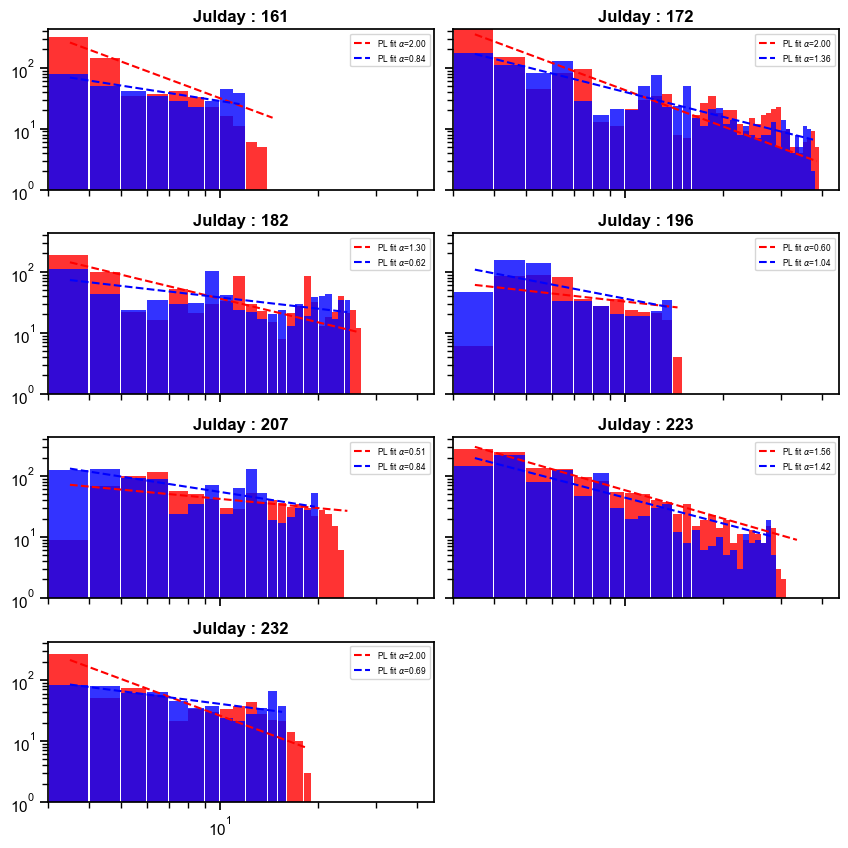

In [98]:
fig, ax = plt.subplots(4,2, sharex=True, sharey=True, figsize=(8.5, 8.5))

for idx, i in enumerate(["1", "3", "4", "6", "7", "8", "9"]):
    label = labels[i]
    julday = event_map[i]['julday'] if type(event_map[i]['julday']) is int else event_map[i]['julday'][0]
    
    bin_heights, bin_edges, _ = ax[idx//2, idx%2].hist(label["Fv [kN]"], bins=np.arange(3,45,1), rwidth=0.97, density=False, alpha=0.8, color="red", log=True)
    fit_and_plot_pl(ax[idx//2, idx%2], bin_heights, bin_edges, "red")
    bin_heights, bin_edges, _ = ax[idx//2, idx%2].hist(globals()[f"dfcomp_{julday}"].Mean_PO, bins=np.arange(3,45,1), rwidth=0.97, density=False, alpha=0.8, color="blue", log=True);
    fit_and_plot_pl(ax[idx//2, idx%2], bin_heights, bin_edges, "blue")
    ax[idx//2, idx%2].set_xscale('log'); ax[idx//2, idx%2].set_xlim(3,45);
    ax[idx//2, idx%2].set_yscale('log'); ax[idx//2, idx%2].set_ylim(bottom=1);
    ax[idx//2, idx%2].set_title(f"Julday : {julday}", fontweight="bold")
    ax[idx//2, idx%2].legend(loc="best", fontsize=6)

    
fig.tight_layout()
fig.delaxes(ax[-1, -1])

In [70]:
bin_edges

array([ 3.,  5.,  7.,  9., 11., 13., 15., 17., 19., 21., 23., 25., 27.,
       29., 31., 33., 35., 37., 39., 41., 43.])

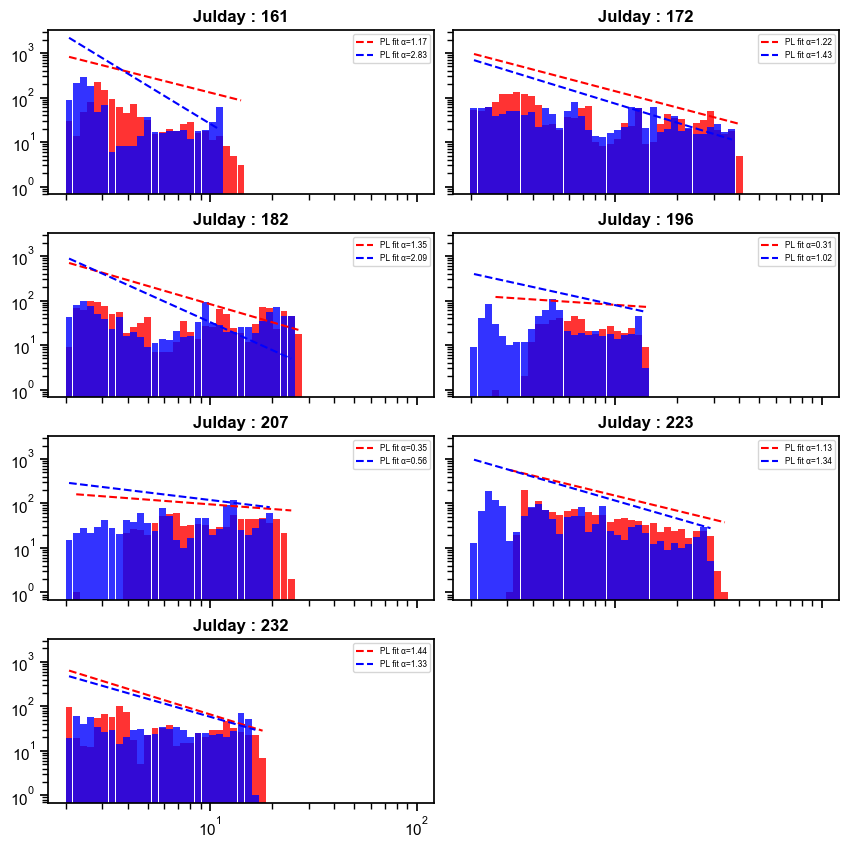

In [79]:
fig, ax = plt.subplots(4,2, sharex=True, sharey=True, figsize=(8.5, 8.5))

for idx, i in enumerate(["1", "3", "4", "6", "7", "8", "9"]):
    label = labels[i]
    julday = event_map[i]['julday'] if type(event_map[i]['julday']) is int else event_map[i]['julday'][0]
    
    bin_heights, bin_edges, _ = ax[idx//2, idx%2].hist(label["Fv [kN]"], bins=np.logspace(0.3,2,50), rwidth=0.97, density=False, alpha=0.8, color="red", log=True)
    fit_and_plot_pl(ax[idx//2, idx%2], bin_heights, bin_edges, "red")
    bin_heights, bin_edges, _ = ax[idx//2, idx%2].hist(globals()[f"dfcomp_{julday}"].Mean_PO, bins=np.logspace(0.3,2,50), rwidth=0.97, density=False, alpha=0.8, color="blue", log=True);
    fit_and_plot_pl(ax[idx//2, idx%2], bin_heights, bin_edges, "blue")
    ax[idx//2, idx%2].set_xscale('log')
    ax[idx//2, idx%2].set_yscale('log')
    ax[idx//2, idx%2].set_title(f"Julday : {julday}", fontweight="bold")
    ax[idx//2, idx%2].legend(loc="best", fontsize=6)
    
fig.tight_layout()
fig.delaxes(ax[-1, -1])

161
172
182
196
207
223
232


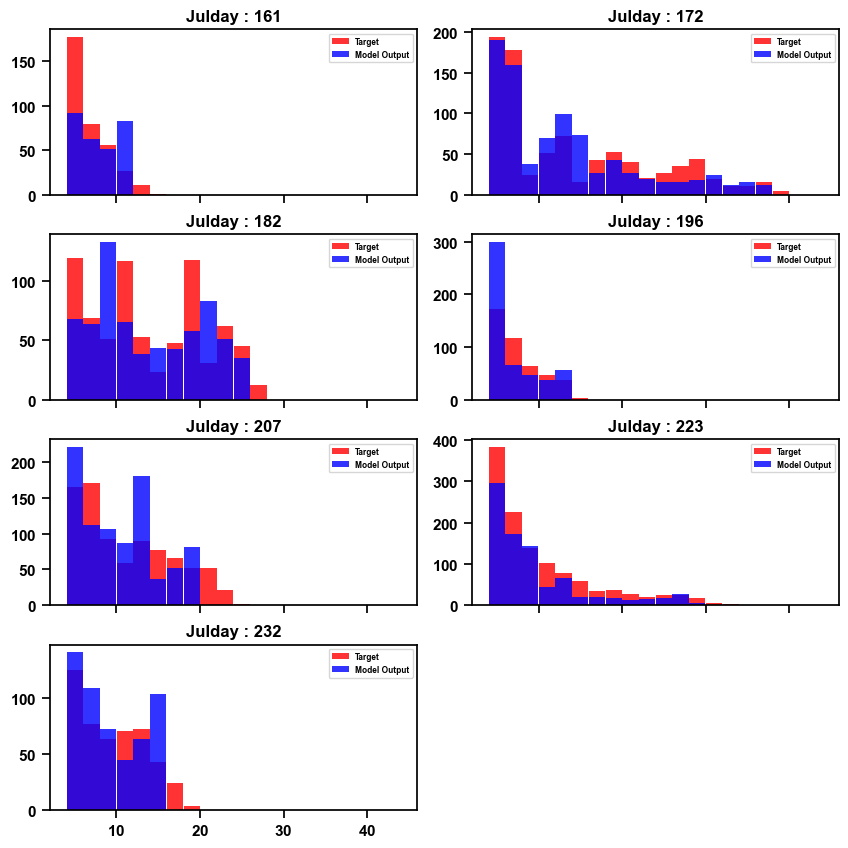

In [ ]:
fig, ax = plt.subplots(4,2, sharex=True, sharey=False, figsize=(8.5, 8.5))

for idx, i in enumerate(["1", "3", "4", "6", "7", "8", "9"]):
    label = labels[i]
    julday = event_map[i]['julday'] if type(event_map[i]['julday']) is int else event_map[i]['julday'][0]
    # print(julday)
    bin_heights, bin_edges, _ = ax[idx//2, idx%2].hist(label["Fv [kN]"], bins=np.arange(4,45,2), rwidth=0.97, density=False, alpha=0.8, color="red", log=False, label="Target")
    # fit_and_plot_pl(ax[idx//2, idx%2], bin_heights, bin_edges, "red")
    bin_heights, bin_edges, _ = ax[idx//2, idx%2].hist(globals()[f"dfcomp_{julday}"].Mean_PO, bins=np.arange(4,45,2), rwidth=0.97, density=False, alpha=0.8, color="blue", log=False, label="Model Output");
    # fit_and_plot_pl(ax[idx//2, idx%2], bin_heights, bin_edges, "blue")
    # ax[idx//2, idx%2].set_xscale('log')
    # ax[idx//2, idx%2].set_yscale('log')
    ax[idx//2, idx%2].set_title(f"Julday : {julday}", fontweight="bold")
    ax[idx//2, idx%2].legend(loc="best", fontsize=6)
    
fig.tight_layout()
fig.delaxes(ax[-1, -1])
fig.savefig("./output_images4/results/distributions.png")

# Images for methodology

In [4]:
plt.rcParams.update( {'font.size':7,
                      'axes.formatter.limits': (-3, 6),
                      'axes.formatter.use_mathtext': True} )

In [5]:
event_id_map["3"]

{'date': '2019-06-21',
 'julday': 172,
 'start_time': '2019-06-21T19:30:00',
 'end_time': '2019-06-21T22:30:00'}

/opt/anaconda3/envs/xlstm_env/lib/python3.12/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/anaconda3/envs/xlstm_env/lib/python3.12/site-packages/obspy/imaging/waveform.py:815: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


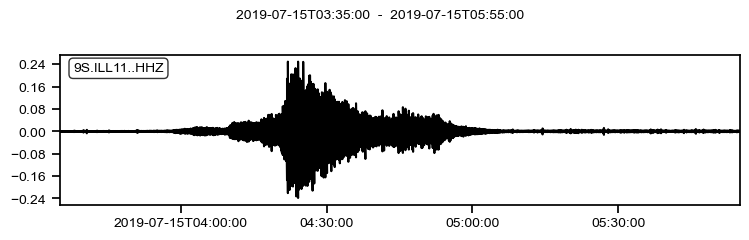

In [51]:
st = load_seismic_data("6", "ILL11", 2019, trim=False)
data, ts = load_data("6", station="ILL11")
# st.trim(starttime=UTCDateTime("2019-06-21T19:30:00"), endtime=UTCDateTime("2019-06-21T22:30:00"))
# st.trim(starttime=UTCDateTime("2019-07-15T04:00:00"), endtime=UTCDateTime("2019-07-15T05:30:00"))
# st.trim(starttime=UTCDateTime("2019-07-01T23:00:00"), endtime=UTCDateTime("2019-07-02T02:30:00"))
st.trim(UTCDateTime(event_id_map["6"]['start_time']) - 1500, UTCDateTime(event_id_map["6"]['end_time']) + 1500)
st.plot();
# df_base = pd.read_csv("../label/utc0_data/20190621_Fv.csv", index_col=0)
# df_base = pd.read_csv("../label/utc0_data/20190715_Fv.csv", index_col=0)
# df_base = pd.read_csv("../label/utc0_data/20190811_Fv.csv", index_col=0)
# df_base = pd.read_csv("../label/utc0_data/20190702_Fv.csv", index_col=0)
# df_base['Time UTC+0'] = df_base['Time UTC+0'].apply(lambda x: UTCDateTime(x))
# df_base['Fv [kN]'] = df_base['Fv [kN]'].apply(lambda x: x/8)
df_base = load_label(["6"], "ILL11", 5, "raw", False, None, None)
df = load_label(["6"], "ILL11", 5, "average", False, None, None)
df2 = load_label(["6"], "ILL11", 5, "average", True, 60, None)

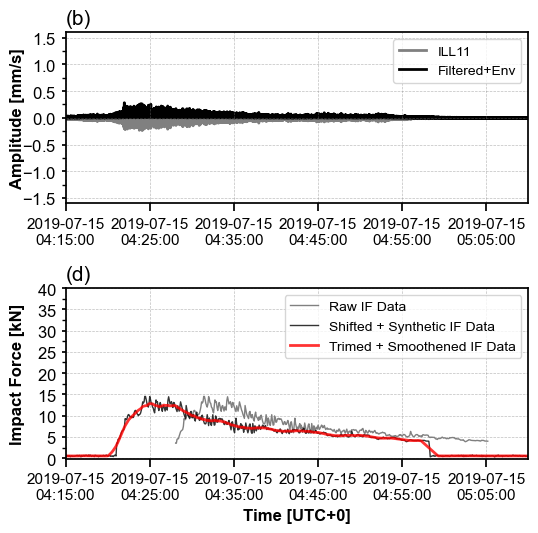

In [53]:
# fig, ax = plt.subplots(1, 1, figsize=(5.5,3.5), sharex=True)
# ax.plot(st[0].times('matplotlib'), st[0].data, color='k', label="ILL11 data", linewidth=0.7, zorder=0)
# ax.plot(ts, data, color='grey', label="Processed ILL11 data", linewidth=1, zorder=1)

# ax.set_ylim(-1.6, 1.6);
# ax.set_ylabel("Amplitude [mm/s]", weight='bold', fontsize=7)
# ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
# ax.yaxis.set_major_locator(MultipleLocator(0.5))
# ax.yaxis.set_minor_locator(MultipleLocator(0.1))
# ax.tick_params(axis='both', which='major', labelsize=10, length=3)
# ax.tick_params(axis='y', which='minor', labelsize=10, length=3)
# ax.set_ylabel("Amplitude [mm/s]", fontweight='bold', fontsize=10)
# ax.set_xlabel(f"Time [UTC+0]", fontweight='bold', fontsize=10)
# ax.xaxis_date()
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M:%S'))
# ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
# # ax.set_xlim(st[0].times('matplotlib')[0], st[0].times('matplotlib')[-1])
# # ax.set_xlim(UTCDateTime("2019-06-21T19:40:00").matplotlib_date, UTCDateTime("2019-06-21T20:30:00").matplotlib_date)
# ax.set_xlim(UTCDateTime("2019-07-15T04:15:00").matplotlib_date, UTCDateTime("2019-07-15T05:05:00").matplotlib_date)
# ax.grid(axis='y', color='grey', linestyle='--', lw=0.5, alpha=0.5, zorder=0)
# ax.legend(loc='upper right', fontsize=7)
# fig.tight_layout()
# fig.savefig("./output_images5/example_seis_processing_196-zoom.png", dpi=600)
# plt.close(fig=fig)
# ax_t = ax.twinx()
fig, ax = plt.subplots(2, 1, figsize=(5.5,5.5), sharex=True)
l2 = ax[1].plot(df_base['Timestamp'].apply(lambda x: UTCDateTime(x).matplotlib_date), df_base['Fv [kN]'], label="Raw IF Data", color="grey", linewidth=1)
l3 = ax[1].plot(df['Timestamp'].apply(lambda x: UTCDateTime(x).matplotlib_date), df['Fv [kN]'], label="Shifted + Synthetic IF Data", color="k", linewidth=1, alpha=0.8)
l4 = ax[1].plot(df2['Timestamp'].apply(lambda x: UTCDateTime(x).matplotlib_date), df2['Fv [kN]'], label="Trimed + Smoothened IF Data", color="r", linewidth=2, alpha=0.8)
ax[1].set_ylim(-0.2, 40);
ax[1].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax[1].yaxis.set_major_locator(MultipleLocator(5))
ax[1].yaxis.set_minor_locator(MultipleLocator(2.5))
ax[1].tick_params(axis='y', which='major', labelsize=12, length=3)
ax[1].tick_params(axis='y', which='minor', labelsize=12, length=3)
ax[1].set_xlabel(f"Time [UTC+0]", fontweight='bold', fontsize=12)
ax[1].set_ylabel("Impact Force [kN]", fontweight='bold', fontsize=12)
ax[1].xaxis_date()
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M:%S'))
ax[1].xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
start = UTCDateTime("2019-07-15T04:15:00").matplotlib_date
end = UTCDateTime("2019-07-15T05:10:00").matplotlib_date
ax[1].set_xticks(np.arange(start, end + 1e-9, 10 / (24 * 60)))  # 10-minute ticks starting at start
# ax.set_xlim(st[0].times('matplotlib')[0], st[0].times('matplotlib')[-1])
# ax[1].set_xlim(UTCDateTime("2019-06-21T19:40:00").matplotlib_date, UTCDateTime("2019-06-21T20:30:00").matplotlib_date)
ax[1].set_xlim(UTCDateTime("2019-07-15T04:15:00").matplotlib_date, UTCDateTime("2019-07-15T05:10:00").matplotlib_date)
ax[1].legend(loc='upper right', fontsize=10)
ax[1].grid(axis='both', color='grey', linestyle='--', lw=0.5, alpha=0.5, zorder=0)
ax[1].set_title("(d)", loc="left", fontsize=15)

l0 = ax[0].plot(st[0].times('matplotlib'), st[0].data, color="grey", linewidth=2, zorder=0, label="ILL11")
l1 = ax[0].plot(ts, data, color="k", linewidth=2, zorder=1, label="Filtered+Env")

# ax.set_xlabel(f"Time [UTC+0]", fontweight='bold', fontsize=12)
ax[0].set_ylabel("Amplitude [mm/s]", fontweight='bold', fontsize=12)
# ax.xaxis_date()
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M:%S'))
# ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
# start = UTCDateTime("2019-07-15T04:15:00").matplotlib_date
# end = UTCDateTime("2019-07-15T05:10:00").matplotlib_date
# ax.set_xticks(np.arange(start, end + 1e-9, 10 / (24 * 60)))  # 10-minute ticks starting at start
# ax.set_xlim(st[0].times('matplotlib')[0], st[0].times('matplotlib')[-1])
# ax.set_xlim(UTCDateTime("2019-06-21T19:40:00").matplotlib_date, UTCDateTime("2019-06-21T20:30:00").matplotlib_date)
# ax.set_xlim(UTCDateTime("2019-07-15T04:15:00").matplotlib_date, UTCDateTime("2019-07-15T05:10:00").matplotlib_date)
ax[0].set_ylim(-1.6, 1.6)
ax[0].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax[0].yaxis.set_major_locator(MultipleLocator(0.5))
ax[0].yaxis.set_minor_locator(MultipleLocator(0.25))
ax[0].tick_params(axis='y', which='major', labelsize=12, length=3)
ax[0].tick_params(axis='y', which='minor', labelsize=12, length=3)
ax[0].grid(axis='both', color='grey', linestyle='--', lw=0.5, alpha=0.5, zorder=0)
ax[0].legend(loc='upper right', fontsize=10)
ax[0].set_title("(b)", loc="left", fontsize=15)
for axis, label in zip(ax, ["Amplitude [mm/s]", "Impact Force [kN]"]):
    axis.set_ylabel("")
    axis.text(
        -0.12,
        0.5,
        label,
        transform=axis.transAxes,
        rotation="vertical",
        va="center",
        ha="left",
        fontweight="bold",
        fontsize=12,
    )
# ax[0].xaxis_date()
# ax[0].xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
# ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax[0].tick_params(axis='x', labelbottom=True)
plt.setp(ax[0].get_xticklabels(), visible=True)
fig.subplots_adjust(left=0.15)
fig.tight_layout()
fig.savefig("./output_images15/example_processing_196-zoom.png", dpi=600)
# plt.close(fig=fig)

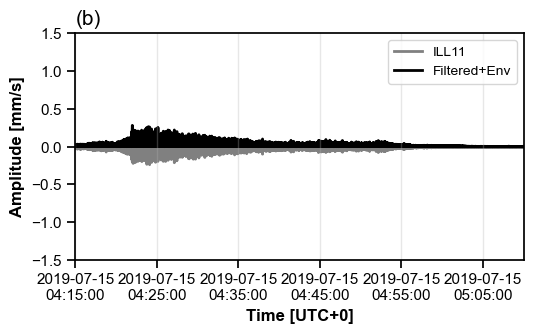

In [35]:
# fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))

# ax_t = ax.twinx()
l0 = ax.plot(st[0].times('matplotlib'), st[0].data, color="grey", linewidth=2, zorder=0, label="ILL11")
l1 = ax.plot(ts, data, color="k", linewidth=2, zorder=1, label="Filtered+Env")

ax.set_xlabel(f"Time [UTC+0]", fontweight='bold', fontsize=12)
ax.set_ylabel("Amplitude [mm/s]", fontweight='bold', fontsize=12)
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M:%S'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
start = UTCDateTime("2019-07-15T04:15:00").matplotlib_date
end = UTCDateTime("2019-07-15T05:10:00").matplotlib_date
ax.set_xticks(np.arange(start, end + 1e-9, 10 / (24 * 60)))  # 10-minute ticks starting at start
# ax.set_xlim(st[0].times('matplotlib')[0], st[0].times('matplotlib')[-1])
# ax.set_xlim(UTCDateTime("2019-06-21T19:40:00").matplotlib_date, UTCDateTime("2019-06-21T20:30:00").matplotlib_date)
ax.set_xlim(UTCDateTime("2019-07-15T04:15:00").matplotlib_date, UTCDateTime("2019-07-15T05:10:00").matplotlib_date)
ax.set_ylim(-1.5, 1.5)
ax.grid(True, alpha=0.3, axis="x")
ax.legend(loc='upper right', fontsize=10)
ax.set_title("(b)", loc="left", fontsize=15)
fig.tight_layout()
fig.savefig("./output_images15/example_seis_processing_196-zoom.png", dpi=600)

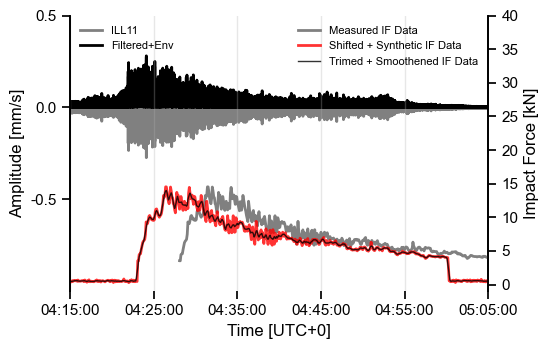

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))

ax_t = ax.twinx()
l0 = ax.plot(st[0].times('matplotlib'), st[0].data, color="grey", linewidth=2, zorder=0, label="ILL11")
l1 = ax.plot(ts, data, color="k", linewidth=2, zorder=1, label="Filtered+Env")

l2 = ax_t.plot(df_base['Timestamp'].apply(lambda x: UTCDateTime(x).matplotlib_date), df_base['Fv [kN]'], label="Measured IF Data", color="grey", linewidth=2, zorder=0)
l3 = ax_t.plot(df['Timestamp'].apply(lambda x: UTCDateTime(x).matplotlib_date), df['Fv [kN]'], label="Shifted + Synthetic IF Data", color="r", linewidth=2, alpha=0.8, zorder=0)
l4 = ax_t.plot(df2['Timestamp'].apply(lambda x: UTCDateTime(x).matplotlib_date), df2['Fv [kN]'], label="Trimed + Smoothened IF Data", color="k", linewidth=1, alpha=0.8, zorder=1)

ax.set_xlim(UTCDateTime("2019-07-15T04:15:00").matplotlib_date, UTCDateTime("2019-07-15T05:05:00").matplotlib_date)
ax.set_ylim(-1, 0.5)
ax.set_yticks([-0.5, 0, 0.5], ["-0.5", "0.0", "0.5"])
ax_t.set_ylim(-1,40)
ax_t.set_yticks(np.arange(0,41,5), np.arange(0,41,5))

ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))

ax.set_ylabel("Amplitude [mm/s]", fontsize=12)
ax.set_xlabel(f"Time [UTC+0]", fontsize=12)
ax_t.set_ylabel("Impact Force [kN]", fontsize=12)

ax.spines['top'].set_visible(False)
ax_t.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax_t.spines['bottom'].set_visible(False)

lns = l0+l1
labs = [l.get_label() for l in lns]
leg = ax.legend(lns, labs, loc='upper left', fontsize=8)
if leg:
    leg.get_frame().set_alpha(0)

lns = l2+l3+l4
labs = [l.get_label() for l in lns]
leg = ax_t.legend(lns, labs, loc='upper right', fontsize=8)
if leg:
    leg.get_frame().set_alpha(0)

ax.grid(True, alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig("./output_images10/preprocessing.png", dpi=600, transparent=True)

In [331]:
import obspy
from obspy import read_inventory

In [329]:
st_base = read("../data/9S.ILL11.EHZ.2019.172.mseed")
# st_base.trim(starttime=UTCDateTime("2019-06-21T18:00:00"), endtime=UTCDateTime("2019-06-21T23:59:59"))
st = st_base.copy()
st.merge(method=1, fill_value='latest', interpolation_samples=0)
st._cleanup()
st.detrend('linear')
st.detrend('demean')
inv = read_inventory(f"../meta_data/9S_2017_2023.xml")
st.remove_response(inventory=inv)
st.filter('highpass', freq=1)
st_filtered = st.copy()
st_filtered.filter('bandpass', freqmin=1, freqmax=15)
st_base.trim(starttime=UTCDateTime("2019-06-21T19:30:00"), endtime=UTCDateTime("2019-06-21T21:00:00"))
st.trim(starttime=UTCDateTime("2019-06-21T19:30:00"), endtime=UTCDateTime("2019-06-21T21:00:00"))
st_filtered.trim(starttime=UTCDateTime("2019-06-21T19:30:00"), endtime=UTCDateTime("2019-06-21T21:00:00"))

/opt/anaconda3/envs/xlstm_env/lib/python3.12/site-packages/obspy/core/inventory/inventory.py:451: UserWarning: Found more than one matching response. Returning first.
  warnings.warn(msg)


1 Trace(s) in Stream:
9S.ILL11..HHZ | 2019-06-21T19:30:00.000000Z - 2019-06-21T21:00:00.000000Z | 100.0 Hz, 540001 samples

In [332]:
st_final = st_filtered.copy()
st_final[0].data = st_final[0].data * 1e3
data_envelope = obspy.signal.filter.envelope(st_final[0].data)
data = data_envelope
data = data[1:]

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(5.5, 5.5), sharex=True)
for axis in ax:
    axis.xaxis_date()
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M:%S'))
    axis.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
    axis.set_xlim(st[0].times('matplotlib')[0], st[0].times('matplotlib')[-1])

ax[0].plot(st_base[0].times('matplotlib'), st_base[0].data, color="black", label="Raw Data", linewidth=0.5)
# ax[1].plot(st[0].times('matplotlib'), st[0].data, color="grey", label="Sensor Response Removed", zorder=0, linewidth=0.5)
# ax[1].plot(st_filtered[0].times('matplotlib'), st_filtered[0].data, color="black", label="1-15Hz Bandpass filter", zorder=1, linewidth=0.5)
ax[1].plot(st_final[0].times('matplotlib')[1:], data, color="black", label="Seismic Envelope", linewidth=0.5)

ax[0].set_ylabel("Counts", fontweight='bold', fontsize=12)
# ax[1].set_ylabel("Amplitude\n[m/s]", fontweight='bold', fontsize=12)
ax[1].set_ylabel("Seismic Env\n[mm/s]", fontweight='bold', fontsize=12)
ax[1].set_xlabel("Time [UTC+0]", fontweight='bold', fontsize=12)

ax[0].set_ylim(-1e6, 1e6);
# ax[1].set_ylim(-2e-3, 2e-3);
ax[1].set_ylim(-0.1, 1.6);


# ax[0].text(0.01, 0.9, "(a)", transform=ax[0].transAxes, fontsize=12, fontweight="bold", va='top', ha='left')
# ax[1].text(0.01, 0.9, "(b)", transform=ax[1].transAxes, fontsize=12, fontweight="bold", va='top', ha='left')
# ax[2].text(0.01, 0.9, "(c)", transform=ax[2].transAxes, fontsize=12, fontweight="bold", va='top', ha='left')
# ax[3].text(0.01, 0.9, "(d)", transform=ax[3].transAxes, fontsize=12, fontweight="bold", va='top', ha='left')

for axis in ax:
    axis.legend(loc="best", fontsize=12)

fig.tight_layout()
fig.subplots_adjust(hspace=0.1)
fig.savefig("./output_images5/seismic_preprocessing.png", dpi=300)
# plt.close(fig=fig)

## Problem Formalisation

In [6]:
from functions.data_processing.dataloader import SequenceDataset, DataLoader

In [25]:
data, ts = load_data(['3'], "ILL11", 2019, True, True, True)
label = load_label(['3'], 'ILL11', 15, 'average', True, 60, None)

<Axes: >

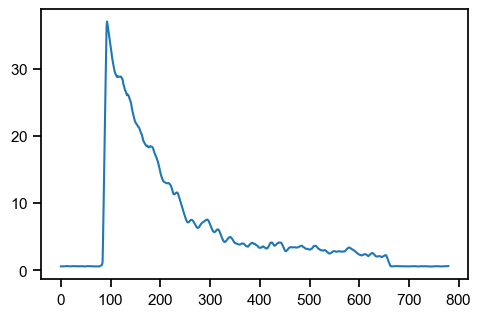

In [26]:
label['Fv [kN]'].plot()

In [27]:
dataset = SequenceDataset(data, label['Fv [kN]'].to_numpy(),
                            label['Timestamp'].to_numpy(),
                            interval_count=20, sequence_length=1500)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)  # Adjust batch size as needed

In [28]:
for i, (input_sequences, target_value, ts) in enumerate(dataloader):
    if target_value[0] > 30:
        break
input_sequences = input_sequences.numpy()
target_value = target_value.numpy()
ts = ts.numpy()

In [29]:
input_sequences.shape

(1, 20, 1500)

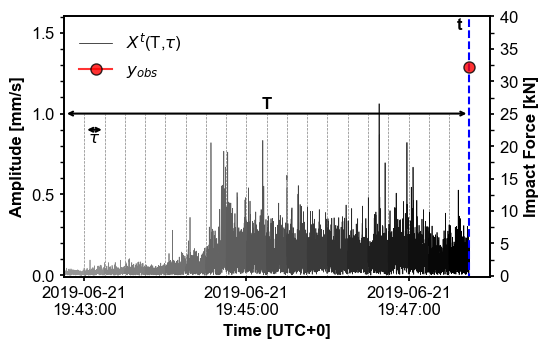

In [32]:
fig, ax = plt.subplots(nrows = input_sequences.shape[0], ncols=1, figsize=(5.5, 3.5), sharex=True)
ax = [ax]
for j in range(input_sequences.shape[0]):
    t = [((UTCDateTime(ts[j]) - 300) + i / 100).matplotlib_date for i in range(20*1500)]
    for i in range(input_sequences.shape[1]):
        color_value = 0.5 + i * (0.5 / (input_sequences.shape[1] - 1))
        if i == 19:
            l1 = ax[j].plot(t[i*1500:(i+1)*1500], input_sequences[j,i], color=plt.cm.Greys(color_value), linewidth=0.5, label=r"$X^{t}$(T,$\tau$)", zorder=1)
        else:
            ax[j].plot(t[i*1500:(i+1)*1500], input_sequences[j,i], color=plt.cm.Greys(color_value), linewidth=0.5, zorder=1)
    
    ax[j].xaxis_date()
    ax[j].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M:%S"))
    ax[j].xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
    ax[j].set_ylim(-0.01, 1.6)
    ax[j].set_ylabel("Amplitude [mm/s]", fontweight='bold', fontsize=12)
    ax[j].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax[j].yaxis.set_major_locator(MultipleLocator(0.5))
    ax[j].yaxis.set_minor_locator(MultipleLocator(0.1))
    ax[j].tick_params(axis='both', which='major', labelsize=12, length=3)
    ax[j].tick_params(axis='y', which='minor', labelsize=12, length=3)
    ax[j].set_xlabel(f"Time [UTC+0]", fontweight='bold', fontsize=12)
    ax_t = ax[j].twinx()
    l2 = ax_t.plot(UTCDateTime(ts[j].item()).matplotlib_date, target_value[j].item(), color="r", marker="o", markersize=8, markeredgecolor="k", alpha=0.8, label=r"$y_{obs}$")
    ax_t.set_ylim(-0.2, 40);
    ax_t.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax_t.yaxis.set_major_locator(MultipleLocator(5))
    ax_t.yaxis.set_minor_locator(MultipleLocator(2.5))
    ax_t.tick_params(axis='y', which='major', labelsize=12, length=3)
    ax_t.tick_params(axis='y', which='minor', labelsize=12, length=3)
    
    lns = l1+l2
    labs = [l.get_label() for l in lns]
    leg = ax[j].legend(lns, labs, loc='upper left', fontsize=12)

    ax_t.set_ylabel("Impact Force [kN]", fontweight='bold', fontsize=12)
    if j == 0:
        ax[j].set_xlim(left=t[0])
    # if j == 5:
    #     ax[j].set_xlim(right=t[-1])
ax[0].annotate('', xy=(t[0], 1), xytext=(t[-1], 1),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5), alpha=0.5)
ax[0].text((t[0] + t[-1]) / 2, 1.01, 'T', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax[0].annotate('', xy=(t[1500], 0.9), xytext=(t[3000], 0.9),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax[0].text((t[1500] + t[3000]) / 2, 0.80, r'$\tau$', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax[0].vlines(t[-1], ymin=-0.1, ymax=2, linestyle = "--", lw=1.5, color="blue")
ax[0].text(t[-700], 1.5, "t", ha='center', va='bottom', fontweight='bold', fontsize=12)
for i in range(input_sequences.shape[1]):
    ax[0].vlines(t[i*1500], ymin=-0.1, ymax=1, linestyle="--", lw=0.5, color="grey", zorder=0)
# leg = ax[0].get_legend()
if leg:
    leg.get_frame().set_alpha(0)
fig.tight_layout()
fig.savefig("./output_images/problem_formalistation.png", dpi=600, transparent=True)

## LOOCV

In [146]:
labelt = load_label("3", "ILL11", 5, "average", True, 60, None)

In [158]:
labelv = load_label("7", "ILL11", 5, "average", True, 60, None)
label = load_label(["1", "4", "5", "6", "8", "9"], "ILL11", 5, "average", True, 60, None)
print(len(labelt),len(labelv),len(label))

2340 1980 12420


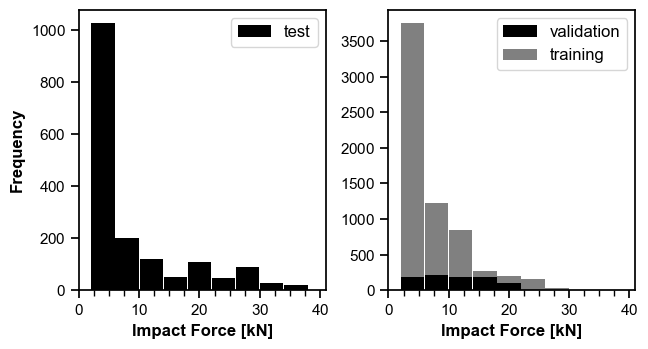

In [159]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=False, figsize=(6.5, 3.5))

ax[0].hist(labelt['Fv [kN]'], bins=np.arange(2, 45, 4), rwidth=0.97, color="k", label="test");
ax[1].hist(labelv['Fv [kN]'], bins=np.arange(2, 45, 4), rwidth=0.97, zorder=1, color="k", label="validation");
ax[1].hist(label['Fv [kN]'], bins=np.arange(2, 45, 4), rwidth=0.97, zorder=0, color="grey", label="training");

for axes in ax:
    axes.legend(loc="upper right", fontsize=12)
    axes.set_xlim(0, 41)
    axes.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    axes.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    axes.xaxis.set_minor_locator(MultipleLocator(2.5))
    axes.xaxis.set_major_locator(MultipleLocator(10))
    axes.set_xlabel("Impact Force [kN]", fontsize=12, fontweight="bold")
ax[0].set_ylabel("Frequency", fontsize=12, fontweight="bold")

fig.tight_layout()
fig.savefig("./output_images5/LOOCV_172_207.png", dpi=300)

In [154]:
labelv = load_label("1", "ILL11", 5, "average", True, 60, None)
label = load_label(["4", "5", "6", "7", "8", "9"], "ILL11", 5, "average", True, 60, None)
print(len(labelt),len(labelv),len(label))

2340 1800 12600


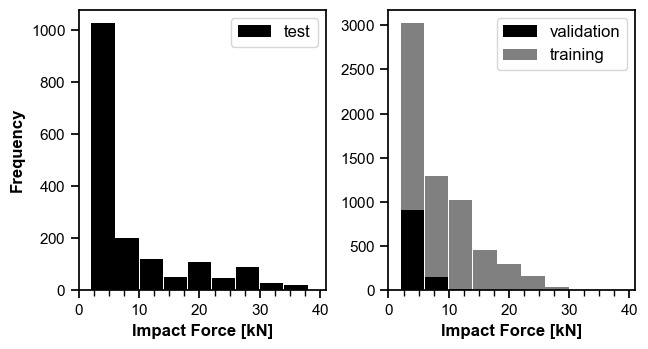

In [157]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=False, figsize=(6.5, 3.5))

ax[0].hist(labelt['Fv [kN]'], bins=np.arange(2, 45, 4), rwidth=0.97, color="k", label="test");
ax[1].hist(labelv['Fv [kN]'], bins=np.arange(2, 45, 4), rwidth=0.97, zorder=1, color="k", label="validation");
ax[1].hist(label['Fv [kN]'], bins=np.arange(2, 45, 4), rwidth=0.97, zorder=0, color="grey", label="training");

for axes in ax:
    axes.legend(loc="upper right", fontsize=12)
    axes.set_xlim(0, 41)
    axes.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    axes.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    axes.xaxis.set_minor_locator(MultipleLocator(2.5))
    axes.xaxis.set_major_locator(MultipleLocator(10))
    axes.set_xlabel("Impact Force [kN]", fontsize=12, fontweight="bold")
ax[0].set_ylabel("Frequency", fontsize=12, fontweight="bold")

fig.tight_layout()
fig.savefig("./output_images5/LOOCV_172_161.png", dpi=300)

In [64]:
# 0.14, 0.09, 0.06, 0.03, 0.05, 0.09, 0.05

In [65]:
# fig, ax = plt.subplots()

# ax.plot(label.Timestamp.apply(lambda x: UTCDateTime(x).matplotlib_date), label['Fv [kN]'])
# ax.plot(t.Timestamp.apply(lambda x: UTCDateTime(x).matplotlib_date), t['Fv [kN]'])

# Loss Curves

In [7]:
# lc11 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/loss_curves/v4/5/xLSTM_t161_v196.txt", sep=";")
# lc12 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/loss_curves/v4/5/LSTM_t161_v183.txt", sep=";")
# lc11 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/loss_curves/v4/5/xLSTM_t172_v207.txt", sep=";")
# lc12 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/loss_curves/v4/5/LSTM_t172_v207.txt", sep=";")
# lc11 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/loss_curves/v4/5/xLSTM_t182_v183.txt", sep=";")
# lc12 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/loss_curves/v4/5/LSTM_t182_v172.txt", sep=";")
# lc11 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/loss_curves/v4/5/xLSTM_t196_v182.txt", sep=";")
# lc12 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/loss_curves/v4/5/LSTM_t196_v223.txt", sep=";")
# lc11 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/loss_curves/v4/5/xLSTM_t207_v172.txt", sep=";")
# lc12 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/loss_curves/v4/5/LSTM_t207_v223.txt", sep=";")
# lc11 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/loss_curves/v4/5/xLSTM_t223_v207.txt", sep=";")
# lc12 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/loss_curves/v4/5/LSTM_t223_v207.txt", sep=";")
# lc11 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/loss_curves/v4/5/xLSTM_t232_v161.txt", sep=";")
# lc12 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/loss_curves/v4/5/LSTM_t232_v196.txt", sep=";")
# lc11 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/best_loss_curves/v4/xLSTM_5_232.txt", sep=";")
# lc12 = pd.read_csv("../comparison_baseline_cv_5_15_1/average_60_45/best_loss_curves/v4/LSTM_5_232.txt", sep=";")
f = 172
lc11 = pd.read_csv(f"../comparison_baseline_tt_5_15_1/average_60_45/loss_curves/v4/5/xLSTM_t{f}_v{f}.txt", sep=";")
lc12 = pd.read_csv(f"../comparison_baseline_tt_5_15_1/average_60_45/loss_curves/v4/5/LSTM_t{f}_v{f}.txt", sep=";")

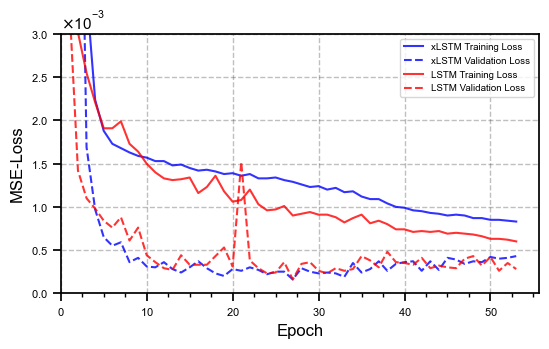

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5), sharey=True)
alpha=0.8
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(2.5))
ax.tick_params(axis='both', which='major', labelsize=8, length=6)
ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
ax.set_xticks(range(0, 80+1, 10))

ax.plot(lc11['Epoch'], lc11['Train_Loss'], label="xLSTM Training Loss", alpha=alpha, color="blue")
ax.plot(lc11['Epoch'], lc11['Val_Loss'], label="xLSTM Validation Loss", alpha=alpha, color="blue", linestyle="--")

ax.plot(lc12['Epoch'], lc12['Train_Loss'], label="LSTM Training Loss", alpha=alpha, color="red")
ax.plot(lc12['Epoch'], lc12['Val_Loss'], label="LSTM Validation Loss", alpha=alpha, color="red", linestyle="--")

ax.set_ylim(0, 0.003)
ax.set_xlim(left=0)
ax.legend(loc="upper right", fontsize=7)
ax.grid(True, alpha=0.25, linestyle="--", color="k")
ax.set_ylabel("MSE-Loss")
ax.set_xlabel("Epoch")
fig.tight_layout()
# fig.savefig("./output_images7/232-Loss-Curves.png", dpi=600)

In [ ]:
lc11 = pd.read_csv("../comparison_baseline_tt_5_15_1/average_60_45/loss_curves/v4/5/xLSTM_t172_v172.txt", sep=";")
lc12 = pd.read_csv("../comparison_baseline_tt_5_15_1/average_60_45/loss_curves/v4/5/LSTM_t172_v172.txt", sep=";")

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5), sharey=True)
alpha=0.8
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(2.5))
ax.tick_params(axis='both', which='major', labelsize=8, length=6)
ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
ax.set_xticks(range(0, 80+1, 10))

ax.plot(lc11['Epoch'], lc11['Train_Loss'], label="xLSTM Training Loss", alpha=alpha, color="blue")
ax.plot(lc11['Epoch'], lc11['Val_Loss'], label="xLSTM Validation Loss", alpha=alpha, color="blue", linestyle="--")

ax.plot(lc12['Epoch'], lc12['Train_Loss'], label="LSTM Training Loss", alpha=alpha, color="red")
ax.plot(lc12['Epoch'], lc12['Val_Loss'], label="LSTM Validation Loss", alpha=alpha, color="red", linestyle="--")

ax.set_ylim(0, 0.003)
ax.set_xlim(left=0)
ax.legend(loc="upper right", fontsize=7)
ax.grid(True, alpha=0.25, linestyle="--", color="k")
ax.set_ylabel("MSE-Loss")
ax.set_xlabel("Epoch")
fig.tight_layout()

# MSE Images

In [49]:
from matplotlib.patches import Rectangle

def highlight_row_mins(pivot, axis, cols):
    cols_present = [c for c in cols if c in pivot.columns]
    for row in [r for r in pivot.index if r in range(1,8)]:
        if row not in pivot.index:
            continue
        row_vals = pivot.loc[row, cols_present]
        if row_vals.isna().all():
            continue
        # find the column with minimum value for this row (among cols_present)
        try:
            min_col = row_vals.astype(float).idxmin()
        except Exception:
            continue
        if pd.isna(min_col):
            continue
        # compute 0-based positions for rectangle
        x_pos = list(pivot.columns).index(min_col)
        y_pos = list(pivot.index).index(row)
        # add rectangle (non-filled red box)
        rect = Rectangle((x_pos, y_pos), 1, 1, fill=False, edgecolor='red', lw=1, zorder=10)
        axis.add_patch(rect)

# helper to format annotations "mean ± se" (empty string for NaNs)
def make_annot(mean_df, se_df, fmt_mean="{:.2f}", fmt_se="{:.2f}"):
    annot = mean_df.copy().astype(object)
    for i in mean_df.index:
        for j in mean_df.columns:
            m = mean_df.at[i, j]
            s = se_df.at[i, j]
            if pd.isna(m):
                annot.at[i, j] = ""
            else:
                annot.at[i, j] = f"{fmt_mean.format(m)}±\n{fmt_se.format(s if not pd.isna(s) else 0.0)}"
    return annot

In [50]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


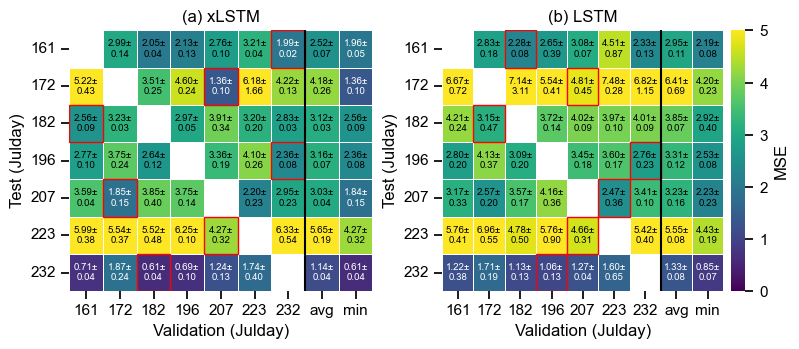

In [67]:
filename = "evaluation_output_constrained.txt"
interval = 5
config = "v4"
plot_xLSTM, plot_LSTM = None, None
for task in ["comparison_baseline_cv_5_30_0", "comparison_baseline_cv_5_30_3", "comparison_baseline_cv_5_30_4"]:
# for task in ["comparison_baseline_cv_5_15_11", "comparison_baseline_cv_5_15_21", "comparison_baseline_cv_5_15_31"]:
    df1 = pd.read_csv(f"../{task}/average_60_45/model_evaluation/{filename}")
    df1 = df1[(df1['Config'] == config) & (df1['Interval'] == interval) & (df1['Model'] == 'xLSTM') & (df1['Test'] != 183) & (df1['Val'] != 183)].copy()
    df1.reset_index(inplace=True, drop=True)
    mapping = {161 : 1, 172 : 2, 182 : 3, 196 : 4, 207 : 5, 223 : 6, 232 : 7}
    df1['x'] = df1['Test'].apply(lambda x : mapping[x])
    df1['y'] = df1['Val'].apply(lambda x : mapping[x])
    plot_df1 = df1[["x", "y", "MSE"]]
    x = plot_df1.groupby("x")['MSE'].agg(['mean']).index.to_numpy()
    val = plot_df1.groupby("x")['MSE'].agg(['mean'])['mean'].to_numpy()
    y = [8]*len(x)
    plot_df1 = pd.concat([plot_df1, pd.DataFrame({"x":x ,"y": y,"MSE": val})], axis=0)
    plot_df1.reset_index(inplace=True, drop=True)
    x = plot_df1.groupby("x")['MSE'].agg(['min']).index.to_numpy()
    val = plot_df1.groupby("x")['MSE'].agg(['min'])['min'].to_numpy()
    y = [9]*len(x)
    plot_df1 = pd.concat([plot_df1, pd.DataFrame({"x":x ,"y": y,"MSE": val})], axis=0)
    plot_df1.reset_index(inplace=True, drop=True)
    if plot_xLSTM is None:
        plot_xLSTM = plot_df1.copy()
    else:
        plot_xLSTM = pd.concat([plot_xLSTM, plot_df1], axis=0)

    df2 = pd.read_csv(f"../{task}/average_60_45/model_evaluation/{filename}")
    df2 = df2[(df2['Config'] == config) & (df2['Interval'] == interval) & (df2['Model'] == 'LSTM') & (df2['Test'] != 183) & (df2['Val'] != 183)].copy()
    df2.reset_index(inplace=True, drop=True)
    mapping = {161 : 1, 172 : 2, 182 : 3, 196 : 4, 207 : 5, 223 : 6, 232 : 7}
    df2['x'] = df2['Test'].apply(lambda x : mapping[x])
    df2['y'] = df2['Val'].apply(lambda x : mapping[x])
    plot_df2 = df2[["x", "y", "MSE"]]
    x = plot_df2.groupby("x")['MSE'].agg(['mean']).index.to_numpy()
    val = plot_df2.groupby("x")['MSE'].agg(['mean'])['mean'].to_numpy()
    y = [8]*len(x)
    plot_df2 = pd.concat([plot_df2, pd.DataFrame({"x":x ,"y": y,"MSE": val})], axis=0)
    plot_df2.reset_index(inplace=True, drop=True)
    x = plot_df2.groupby("x")['MSE'].agg(['min']).index.to_numpy()
    val = plot_df2.groupby("x")['MSE'].agg(['min'])['min'].to_numpy()
    y = [9]*len(x)
    plot_df2 = pd.concat([plot_df2, pd.DataFrame({"x":x ,"y": y,"MSE": val})], axis=0)
    plot_df2.reset_index(inplace=True, drop=True)
    if plot_LSTM is None:
        plot_LSTM = plot_df2.copy()
    else:
        plot_LSTM = pd.concat([plot_LSTM, plot_df2], axis=0)

# x = [1, 2, 3, 4, 5, 6, 7]
# val = [np.round(plot_xLSTM[(plot_xLSTM["x"] == i) & (plot_xLSTM["y"] != 8)].nsmallest(3, "MSE")['MSE'].mean(), 2) for i in x]
# y = [9]*len(x)
# plot_xLSTM = pd.concat([plot_xLSTM, pd.DataFrame({"x":x ,"y": y,"MSE": val})], axis=0)
# x = [1, 2, 3, 4, 5, 6, 7]
# val = [np.round(plot_LSTM[(plot_LSTM["x"] == i) & (plot_LSTM["y"] != 8)].nsmallest(3, "MSE")['MSE'].mean(), 2) for i in x]
# y = [9]*len(x)
plot_LSTM = pd.concat([plot_LSTM, pd.DataFrame({"x":x ,"y": y,"MSE": val})], axis=0)
plot_xLSTM.reset_index(drop=True, inplace=True)
plot_LSTM.reset_index(drop=True, inplace=True)
# build pivots for LSTM (mean + se) and prepare annotations "mean ± se"
mapping2 = {161 : 1, 172 : 2, 182 : 3, 196 : 4, 207 : 5, 223 : 6, 232 : 7, "avg": 8, "min": 9}
agg_xl = plot_xLSTM.groupby(['x','y'])['MSE'].agg(['mean','std','count']).reset_index()
agg_xl['se'] = agg_xl['std'] / np.sqrt(agg_xl['count'])

agg_l = plot_LSTM.groupby(['x','y'])['MSE'].agg(['mean','std','count']).reset_index()
agg_l['se'] = agg_l['std'] / np.sqrt(agg_l['count'])

pivot_xl_mean = agg_xl.pivot(index='x', columns='y', values='mean').reindex(index=range(1,10), columns=range(1,10))
pivot_xl_se   = agg_xl.pivot(index='x', columns='y', values='se').reindex(index=range(1,10), columns=range(1,10))

pivot_l_mean = agg_l.pivot(index='x', columns='y', values='mean').reindex(index=range(1,10), columns=range(1,10))
pivot_l_se   = agg_l.pivot(index='x', columns='y', values='se').reindex(index=range(1,10), columns=range(1,10))

annot_xl = make_annot(pivot_xl_mean, pivot_xl_se)
annot_l  = make_annot(pivot_l_mean, pivot_l_se)

# plotting side-by-side heatmaps with annotated "mean ± se"
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create subplots
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(8, 3.5))
ax = [ax0, ax1]

# Set up the divider for the colorbar on the second axis
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.08)

vmin = 0
vmax = 5

# 2. Plot Heatmaps
sns.heatmap(pivot_xl_mean, ax=ax[0], cmap='viridis', cbar=False,
            annot=False, fmt='', mask=pivot_xl_mean.isna(), vmin=vmin, vmax=vmax,
            linewidths=0.5, linecolor='w')

sns.heatmap(pivot_l_mean,  ax=ax[1], cmap='viridis', 
            cbar_ax=cax, cbar_kws={'label': 'MSE'},
            annot=False, fmt='', mask=pivot_l_mean.isna(), vmin=vmin, vmax=vmax,
            linewidths=0.5, linecolor='w')

# 3. Insert (a) and (b) labels at the top left
# Adjust x and y coordinates (e.g., -0.1, 1.05) to fine-tune placement relative to titles
# ax[0].text(0, 1.08, '(a)', transform=ax[0].transAxes, fontsize=12, va='top', ha='right')
# ax[1].text(0, 1.08, '(b)', transform=ax[1].transAxes, fontsize=12, va='top', ha='right')

# Place custom annotations
for axis, annot_df, mean_df in zip(ax, [annot_xl, annot_l], [pivot_xl_mean, pivot_l_mean]):
    for i, row in enumerate(annot_df.index):
        for j, col in enumerate(annot_df.columns):
            text = annot_df.at[row, col]
            if text == "":
                continue
            val = mean_df.at[row, col]
            color = 'white' if (not pd.isna(val) and val < 2) else 'black'
            axis.text(j + 0.5, i + 0.5, text, ha='center', va='center', fontsize=7, color=color)

# Highlight logic
cols_to_check = list(range(1, 8))
highlight_row_mins(pivot_xl_mean, ax[0], cols_to_check)
highlight_row_mins(pivot_l_mean, ax[1], cols_to_check)

# Labels and ticks
order = list(range(1, 10))
inv_map = {v: k for k, v in mapping2.items()}
labelx = [inv_map[i] for i in order]

for axis in ax:
    axis.set_xticklabels(labelx, rotation=0, ha='center')
    axis.set_yticklabels(labelx, rotation=0)
    axis.set_xlabel('Validation (Julday)')
    axis.set_ylabel('Test (Julday)')
    axis.set_ylim(7, 0)
    axis.set_xlim(0, 9)
    axis.axvline(x=7, color='k', linewidth=1.5, zorder=20)

ax[0].set_title('(a) xLSTM')
ax[1].set_title('(b) LSTM')

fig.tight_layout()
fig.savefig(f"./output_images11/Model-Comparison-Heatmap-MSE-{interval}.png", dpi=600)

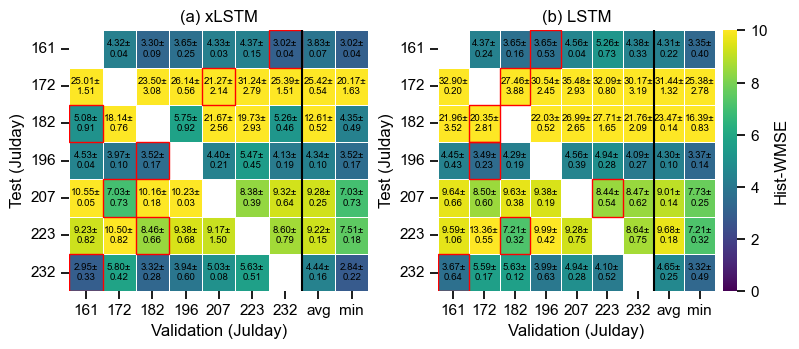

In [72]:
filename = "evaluation_output_constrained.txt"
interval = 5
config = "v4"
plot_xLSTM, plot_LSTM = None, None
for task in ["comparison_baseline_cv_5_30_0", "comparison_baseline_cv_5_30_3", "comparison_baseline_cv_5_30_4"]:
    df1 = pd.read_csv(f"../{task}/average_60_45/model_evaluation/{filename}")
    df1.head()
    df1 = df1[(df1['Config'] == config) & (df1['Interval'] == interval) & (df1['Model'] == 'xLSTM') & (df1['Test'] != 183) & (df1['Val'] != 183)].copy()
    df1.reset_index(inplace=True, drop=True)
    df1.head()
    mapping = {161 : 1, 172 : 2, 182 : 3, 196 : 4, 207 : 5, 223 : 6, 232 : 7}
    df1['x'] = df1['Test'].apply(lambda x : mapping[x])
    df1['y'] = df1['Val'].apply(lambda x : mapping[x])
    plot_df1 = df1[["x", "y", "Hist_WMSE2"]]
    plot_df1.head()
    x = plot_df1.groupby("x")['Hist_WMSE2'].agg(['mean']).index.to_numpy()
    val = plot_df1.groupby("x")['Hist_WMSE2'].agg(['mean'])['mean'].to_numpy()
    y = [8]*len(x)
    plot_df1 = pd.concat([plot_df1, pd.DataFrame({"x":x ,"y": y,"Hist_WMSE2": val})], axis=0)
    plot_df1.reset_index(inplace=True, drop=True)
    x = plot_df1.groupby("x")['Hist_WMSE2'].agg(['min']).index.to_numpy()
    val = plot_df1.groupby("x")['Hist_WMSE2'].agg(['min'])['min'].to_numpy()
    y = [9]*len(x)
    plot_df1 = pd.concat([plot_df1, pd.DataFrame({"x":x ,"y": y,"Hist_WMSE2": val})], axis=0)
    plot_df1.reset_index(inplace=True, drop=True)
    if plot_xLSTM is None:
        plot_xLSTM = plot_df1.copy()
    else:
        plot_xLSTM = pd.concat([plot_xLSTM, plot_df1], axis=0)

    df2 = pd.read_csv(f"../{task}/average_60_45/model_evaluation/{filename}")
    df2 = df2[(df2['Config'] == config) & (df2['Interval'] == interval) & (df2['Model'] == 'LSTM') & (df2['Test'] != 183) & (df2['Val'] != 183)].copy()
    df2.reset_index(inplace=True, drop=True)
    mapping = {161 : 1, 172 : 2, 182 : 3, 196 : 4, 207 : 5, 223 : 6, 232 : 7}
    df2['x'] = df2['Test'].apply(lambda x : mapping[x])
    df2['y'] = df2['Val'].apply(lambda x : mapping[x])
    plot_df2 = df2[["x", "y", "Hist_WMSE2"]]
    x = plot_df2.groupby("x")['Hist_WMSE2'].agg(['mean']).index.to_numpy()
    val = plot_df2.groupby("x")['Hist_WMSE2'].agg(['mean'])['mean'].to_numpy()
    y = [8]*len(x)
    plot_df2 = pd.concat([plot_df2, pd.DataFrame({"x":x ,"y": y,"Hist_WMSE2": val})], axis=0)
    plot_df2.reset_index(inplace=True, drop=True)
    x = plot_df2.groupby("x")['Hist_WMSE2'].agg(['min']).index.to_numpy()
    val = plot_df2.groupby("x")['Hist_WMSE2'].agg(['min'])['min'].to_numpy()
    y = [9]*len(x)
    plot_df2 = pd.concat([plot_df2, pd.DataFrame({"x":x ,"y": y,"Hist_WMSE2": val})], axis=0)
    plot_df2.reset_index(inplace=True, drop=True)
    if plot_xLSTM is None:
        plot_LSTM = plot_df2.copy()
    else:
        plot_LSTM = pd.concat([plot_LSTM, plot_df2], axis=0)
plot_xLSTM.reset_index(drop=True, inplace=True)
plot_LSTM.reset_index(drop=True, inplace=True)
# build pivots for LSTM (mean + se) and prepare annotations "mean ± se"
mapping2 = {161 : 1, 172 : 2, 182 : 3, 196 : 4, 207 : 5, 223 : 6, 232 : 7, "avg": 8, "min": 9}
agg_xl = plot_xLSTM.groupby(['x','y'])['Hist_WMSE2'].agg(['mean','std','count']).reset_index()
agg_xl['se'] = agg_xl['std'] / np.sqrt(agg_xl['count'])

agg_l = plot_LSTM.groupby(['x','y'])['Hist_WMSE2'].agg(['mean','std','count']).reset_index()
agg_l['se'] = agg_l['std'] / np.sqrt(agg_l['count'])
pivot_xl_mean = agg_xl.pivot(index='x', columns='y', values='mean').reindex(index=range(1,10), columns=range(1,10))
pivot_xl_se   = agg_xl.pivot(index='x', columns='y', values='se').reindex(index=range(1,10), columns=range(1,10))

pivot_l_mean = agg_l.pivot(index='x', columns='y', values='mean').reindex(index=range(1,10), columns=range(1,10))
pivot_l_se   = agg_l.pivot(index='x', columns='y', values='se').reindex(index=range(1,10), columns=range(1,10))

annot_xl = make_annot(pivot_xl_mean, pivot_xl_se)
annot_l  = make_annot(pivot_l_mean, pivot_l_se)

# plotting side-by-side heatmaps with annotated "mean ± se"
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create 3 columns: two for the heatmaps (equal width) and one narrow one for the colorbar
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(8, 3.5))
ax = [ax0, ax1] # Keep them in a list for your existing loops
# Set up the divider for the second axis
divider = make_axes_locatable(ax[1])

# MANUALLY ADJUST PADDING HERE:
# pad=0.05 is very tight; pad=0.2 is loose.
cax = divider.append_axes("right", size="5%", pad=0.08)
vmin = 0
vmax = 10

# 2. Plot first heatmap without colorbar
sns.heatmap(pivot_xl_mean, ax=ax[0], cmap='viridis', cbar=False,
            annot=False, fmt='', mask=pivot_xl_mean.isna(), vmin=vmin, vmax=vmax,
            linewidths=0.5, linecolor='w')

# 3. Plot second heatmap using the dedicated cax for the colorbar
sns.heatmap(pivot_l_mean,  ax=ax[1], cmap='viridis', 
            cbar_ax=cax, cbar_kws={'label': 'Hist-WMSE'},
            annot=False, fmt='', mask=pivot_l_mean.isna(), vmin=vmin, vmax=vmax,
            linewidths=0.5, linecolor='w')

# Place custom annotations centered in each cell
for axis, annot_df, mean_df in zip(ax, [annot_xl, annot_l], [pivot_xl_mean, pivot_l_mean]):
    for i, row in enumerate(annot_df.index):
        for j, col in enumerate(annot_df.columns):
            text = annot_df.at[row, col]
            if text == "":
                continue
            val = mean_df.at[row, col]
            color = 'white' if (not pd.isna(val) and val < 2) else 'black'
            axis.text(j + 0.5, i + 0.5, text, ha='center', va='center', fontsize=7, color=color)

# Your highlight function calls
cols_to_check = list(range(1, 8))
highlight_row_mins(pivot_xl_mean, ax[0], cols_to_check)
highlight_row_mins(pivot_l_mean, ax[1], cols_to_check)

# Labels and ticks
order = list(range(1, 10))
inv_map = {v: k for k, v in mapping2.items()}
labelx = [inv_map[i] for i in order]

for i, axis in enumerate(ax):
    axis.set_xticklabels(labelx, rotation=0, ha='center')
    axis.set_yticklabels(labelx, rotation=0)
    axis.set_xlabel('Validation (Julday)')
    axis.set_ylabel('Test (Julday)')
    axis.set_ylim(7, 0)
    axis.set_xlim(0, 9)
    axis.axvline(x=7, color='k', linewidth=1.5, zorder=20)

ax[0].set_title('(a) xLSTM')
ax[1].set_title('(b) LSTM')

fig.tight_layout()
fig.savefig(f"./output_images11/Model-Comparison-Heatmap-HWRMSE-{interval}.png", dpi=600)

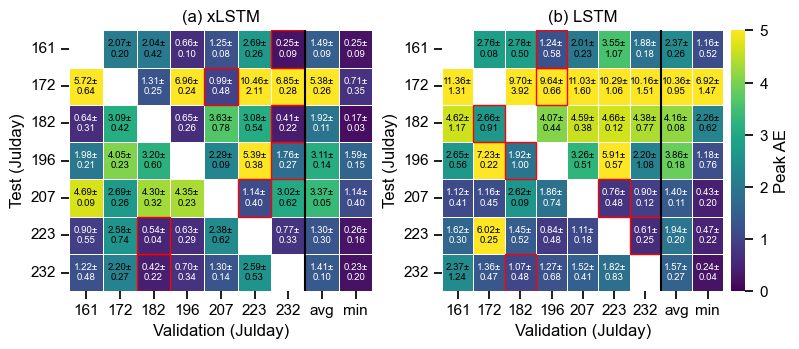

In [75]:
filename = "evaluation_output_constrained.txt"
interval = 5
config = "v4"
plot_xLSTM, plot_LSTM = None, None
for task in ["comparison_baseline_cv_5_30_0", "comparison_baseline_cv_5_30_3", "comparison_baseline_cv_5_30_4"]:
    df1 = pd.read_csv(f"../{task}/average_60_45/model_evaluation/{filename}")
    df1.head()
    df1 = df1[(df1['Config'] == config) & (df1['Interval'] == interval) & (df1['Model'] == 'xLSTM') & (df1['Test'] != 183) & (df1['Val'] != 183)].copy()
    df1.reset_index(inplace=True, drop=True)
    df1.head()
    mapping = {161 : 1, 172 : 2, 182 : 3, 196 : 4, 207 : 5, 223 : 6, 232 : 7}
    df1['x'] = df1['Test'].apply(lambda x : mapping[x])
    df1['y'] = df1['Val'].apply(lambda x : mapping[x])
    plot_df1 = df1[["x", "y", "Peak_Diff"]]
    plot_df1.head()
    x = plot_df1.groupby("x")['Peak_Diff'].agg(['mean']).index.to_numpy()
    val = plot_df1.groupby("x")['Peak_Diff'].agg(['mean'])['mean'].to_numpy()
    y = [8]*len(x)
    plot_df1 = pd.concat([plot_df1, pd.DataFrame({"x":x ,"y": y,"Peak_Diff": val})], axis=0)
    plot_df1.reset_index(inplace=True, drop=True)
    x = plot_df1.groupby("x")['Peak_Diff'].agg(['min']).index.to_numpy()
    val = plot_df1.groupby("x")['Peak_Diff'].agg(['min'])['min'].to_numpy()
    y = [9]*len(x)
    plot_df1 = pd.concat([plot_df1, pd.DataFrame({"x":x ,"y": y,"Peak_Diff": val})], axis=0)
    plot_df1.reset_index(inplace=True, drop=True)
    if plot_xLSTM is None:
        plot_xLSTM = plot_df1.copy()
    else:
        plot_xLSTM = pd.concat([plot_xLSTM, plot_df1], axis=0)

    df2 = pd.read_csv(f"../{task}/average_60_45/model_evaluation/{filename}")
    df2 = df2[(df2['Config'] == config) & (df2['Interval'] == interval) & (df2['Model'] == 'LSTM') & (df2['Test'] != 183) & (df2['Val'] != 183)].copy()
    df2.reset_index(inplace=True, drop=True)
    mapping = {161 : 1, 172 : 2, 182 : 3, 196 : 4, 207 : 5, 223 : 6, 232 : 7}
    df2['x'] = df2['Test'].apply(lambda x : mapping[x])
    df2['y'] = df2['Val'].apply(lambda x : mapping[x])
    plot_df2 = df2[["x", "y", "Peak_Diff"]]
    x = plot_df2.groupby("x")['Peak_Diff'].agg(['mean']).index.to_numpy()
    val = plot_df2.groupby("x")['Peak_Diff'].agg(['mean'])['mean'].to_numpy()
    y = [8]*len(x)
    plot_df2 = pd.concat([plot_df2, pd.DataFrame({"x":x ,"y": y,"Peak_Diff": val})], axis=0)
    plot_df2.reset_index(inplace=True, drop=True)
    x = plot_df2.groupby("x")['Peak_Diff'].agg(['min']).index.to_numpy()
    val = plot_df2.groupby("x")['Peak_Diff'].agg(['min'])['min'].to_numpy()
    y = [9]*len(x)
    plot_df2 = pd.concat([plot_df2, pd.DataFrame({"x":x ,"y": y,"Peak_Diff": val})], axis=0)
    plot_df2.reset_index(inplace=True, drop=True)
    if plot_xLSTM is None:
        plot_LSTM = plot_df2.copy()
    else:
        plot_LSTM = pd.concat([plot_LSTM, plot_df2], axis=0)
plot_xLSTM.reset_index(drop=True, inplace=True)
plot_LSTM.reset_index(drop=True, inplace=True)
# build pivots for LSTM (mean + se) and prepare annotations "mean ± se"
mapping2 = {161 : 1, 172 : 2, 182 : 3, 196 : 4, 207 : 5, 223 : 6, 232 : 7, "avg": 8, "min": 9}
agg_xl = plot_xLSTM.groupby(['x','y'])['Peak_Diff'].agg(['mean','std','count']).reset_index()
agg_xl['se'] = agg_xl['std'] / np.sqrt(agg_xl['count'])

agg_l = plot_LSTM.groupby(['x','y'])['Peak_Diff'].agg(['mean','std','count']).reset_index()
agg_l['se'] = agg_l['std'] / np.sqrt(agg_l['count'])

pivot_xl_mean = agg_xl.pivot(index='x', columns='y', values='mean').reindex(index=range(1,10), columns=range(1,10))
pivot_xl_se   = agg_xl.pivot(index='x', columns='y', values='se').reindex(index=range(1,10), columns=range(1,10))

pivot_l_mean = agg_l.pivot(index='x', columns='y', values='mean').reindex(index=range(1,10), columns=range(1,10))
pivot_l_se   = agg_l.pivot(index='x', columns='y', values='se').reindex(index=range(1,10), columns=range(1,10))

annot_xl = make_annot(pivot_xl_mean, pivot_xl_se)
annot_l  = make_annot(pivot_l_mean, pivot_l_se)

# plotting side-by-side heatmaps with annotated "mean ± se"
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create 3 columns: two for the heatmaps (equal width) and one narrow one for the colorbar
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(8, 3.5))
ax = [ax0, ax1] # Keep them in a list for your existing loops
# Set up the divider for the second axis
divider = make_axes_locatable(ax[1])

# MANUALLY ADJUST PADDING HERE:
# pad=0.05 is very tight; pad=0.2 is loose.
cax = divider.append_axes("right", size="5%", pad=0.08)
vmin = 0
vmax = 5

# 2. Plot first heatmap without colorbar
sns.heatmap(pivot_xl_mean, ax=ax[0], cmap='viridis', cbar=False,
            annot=False, fmt='', mask=pivot_xl_mean.isna(), vmin=vmin, vmax=vmax,
            linewidths=0.5, linecolor='w')

# 3. Plot second heatmap using the dedicated cax for the colorbar
sns.heatmap(pivot_l_mean,  ax=ax[1], cmap='viridis', 
            cbar_ax=cax, cbar_kws={'label': 'Peak AE'},
            annot=False, fmt='', mask=pivot_l_mean.isna(), vmin=vmin, vmax=vmax,
            linewidths=0.5, linecolor='w')

# Place custom annotations centered in each cell
for axis, annot_df, mean_df in zip(ax, [annot_xl, annot_l], [pivot_xl_mean, pivot_l_mean]):
    for i, row in enumerate(annot_df.index):
        for j, col in enumerate(annot_df.columns):
            text = annot_df.at[row, col]
            if text == "":
                continue
            val = mean_df.at[row, col]
            color = 'white' if (not pd.isna(val) and val < 2) else 'black'
            axis.text(j + 0.5, i + 0.5, text, ha='center', va='center', fontsize=7, color=color)

# Your highlight function calls
cols_to_check = list(range(1, 8))
highlight_row_mins(pivot_xl_mean, ax[0], cols_to_check)
highlight_row_mins(pivot_l_mean, ax[1], cols_to_check)

# Labels and ticks
order = list(range(1, 10))
inv_map = {v: k for k, v in mapping2.items()}
labelx = [inv_map[i] for i in order]

for i, axis in enumerate(ax):
    axis.set_xticklabels(labelx, rotation=0, ha='center')
    axis.set_yticklabels(labelx, rotation=0)
    axis.set_xlabel('Validation (Julday)')
    axis.set_ylabel('Test (Julday)')
    axis.set_ylim(7, 0)
    axis.set_xlim(0, 9)
    axis.axvline(x=7, color='k', linewidth=1.5, zorder=20)

ax[0].set_title('(a) xLSTM')
ax[1].set_title('(b) LSTM')

fig.tight_layout()
fig.savefig(f"./output_images11/Model-Comparison-Heatmap-Peak-{interval}.png", dpi=600)

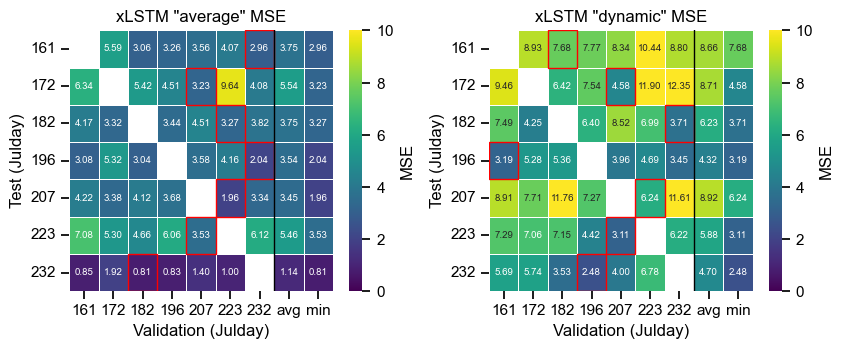

In [18]:
mapping = {161 : 1, 172 : 2, 182 : 3, 196 : 4, 207 : 5, 223 : 6, 232 : 7}
interval = 5
# filename = "evaluation_output_wo_noise.txt"
task = "comparison_baseline_cv_5_15_1"
config = "v5"
filename = "evaluation_output_constrained.txt"
df1 = pd.read_csv(f"../{task}/average_60_45/model_evaluation/{filename}")
df1 = df1[(df1['Config'] == config) & (df1['Interval'] == interval) & (df1['Model'] == 'xLSTM') & (df1['Test'] != 183) & (df1['Val'] != 183)].copy()
df1.reset_index(inplace=True, drop=True)
df1['x'] = df1['Test'].apply(lambda x : mapping[x])
df1['y'] = df1['Val'].apply(lambda x : mapping[x])
plot_df1 = df1[["x", "y", "MSE"]]
x = plot_df1.groupby("x")['MSE'].agg(['mean']).index.to_numpy()
val = plot_df1.groupby("x")['MSE'].agg(['mean'])['mean'].to_numpy()
y = [8]*len(x)
plot_df1 = pd.concat([plot_df1, pd.DataFrame({"x":x ,"y": y,"MSE": val})], axis=0)
plot_df1.reset_index(inplace=True, drop=True)
x = plot_df1.groupby("x")['MSE'].agg(['min']).index.to_numpy()
val = plot_df1.groupby("x")['MSE'].agg(['min'])['min'].to_numpy()
y = [9]*len(x)
plot_df1 = pd.concat([plot_df1, pd.DataFrame({"x":x ,"y": y,"MSE": val})], axis=0)
plot_df1.reset_index(inplace=True, drop=True)

df2 = pd.read_csv(f"../{task}/dynamic_60_45/model_evaluation/{filename}")
df2 = df2[(df2['Config'] == config) & (df2['Interval'] == interval) & (df2['Model'] == 'xLSTM') & (df2['Test'] != 183) & (df2['Val'] != 183)].copy()
df2.reset_index(inplace=True, drop=True)
df2['x'] = df2['Test'].apply(lambda x : mapping[x])
df2['y'] = df2['Val'].apply(lambda x : mapping[x])
plot_df2 = df2[["x", "y", "MSE"]]
x = plot_df2.groupby("x")['MSE'].agg(['mean', 'min']).index.to_numpy()
val1 = plot_df2.groupby("x")['MSE'].agg(['mean', 'min'])['mean'].to_numpy()
val2 = plot_df2.groupby("x")['MSE'].agg(['mean', 'min'])['min'].to_numpy()
y1 = [8]*len(x)
y2 = [9]*len(x)
plot_df2 = pd.concat([plot_df2, pd.DataFrame({"x":x ,"y": y1,"MSE": val1}), pd.DataFrame({"x":x ,"y": y2,"MSE": val2})], axis=0)
plot_df2.reset_index(inplace=True, drop=True)
# x = plot_df2.groupby("x")['MSE'].agg(['min']).index.to_numpy()
# val = plot_df2.groupby("x")['MSE'].agg(['min'])['min'].to_numpy()
# y = [9]*len(x)
# plot_df2 = pd.concat([plot_df2, pd.DataFrame({"x":x ,"y": y,"MSE": val})], axis=0)
# plot_df2.reset_index(inplace=True, drop=True)
# plot_df2.drop_duplicates(inplace=True).reset_index(inplace=True, drop=True)

mapping2 = {161 : 1, 172 : 2, 182 : 3, 196 : 4, 207 : 5, 223 : 6, 232 : 7, "avg": 8, "min": 9}
# heatmap of Hist_WMSE with x (rows) and y (columns)
pivot_df1 = plot_df1.pivot(index='x', columns='y', values='MSE')
order = list(range(1, 10))  # 1..7
pivot_df1 = pivot_df1.reindex(index=order, columns=order)

pivot_df2 = plot_df2.pivot(index='x', columns='y', values='MSE')
order = list(range(1, 10))  # 1..7
pivot_df2 = pivot_df2.reindex(index=order, columns=order)

fig, ax = plt.subplots(1, 2, figsize=(8.5,3.5))
sns.heatmap(
    pivot_df1,
    ax=ax[0],
    cmap='viridis',
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'MSE'},
    mask=pivot_df1.isna(),
    linewidths=0.5,
    linecolor='w',
    vmin=0,
    vmax=10,
)
sns.heatmap(
    pivot_df2,
    ax=ax[1],
    cmap='viridis',
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'MSE'},
    mask=pivot_df2.isna(),
    linewidths=0.5,
    linecolor='w',
    vmin=0,
    vmax=10,
)

cols_to_check = list(range(1, 8))  # 1..7
highlight_row_mins(pivot_df1, ax[0], cols_to_check)
highlight_row_mins(pivot_df2, ax[1], cols_to_check)

ax[0].set_title('xLSTM "average" MSE')
ax[1].set_title('xLSTM "dynamic" MSE')
for axis in ax:
    # map index positions back to julday values and update tick labels
    inv_map = {v: k for k, v in mapping2.items()}  # index -> julday
    labels = [inv_map[i] for i in order]

    axis.set_xticklabels(labels, rotation=0, ha='center')
    axis.set_yticklabels(labels, rotation=0)
    axis.set_xlabel('Validation (Julday)')
    axis.set_ylabel('Test (Julday)')
    axis.set_ylim(7, 0)
    # ensure x-limits match heatmap grid and draw a vertical separator between results (1..7) and avg/min (8..9)
    axis.set_xlim(0, 9)
    axis.axvline(x=7, color='k', linewidth=1, zorder=20)
fig.tight_layout()
fig.savefig(f"./output_images6/Model-Comparison-Heatmap-avd-{interval}.png", dpi=600)

# Better?

In [62]:
per_better = []

per_better.append(np.round((3.36 - 2.95) / 2.95, 4))
per_better.append(np.round((8.37 - 5.94) / 5.94, 4))
per_better.append(np.round((4.00 - 3.27) / 3.27, 4))
per_better.append(np.round((3.53 - 3.42) / 3.42, 4))
per_better.append(np.round((5.37 - 5.20) / 5.20, 4))
per_better.append(np.round((8.09 - 8.04) / 8.04, 4))
per_better.append(np.round((1.63 - 1.44) / 1.44, 4))
per_better = [np.round(i*100, 2) for i in per_better]
print(per_better)
print(np.mean(per_better))
print(np.std(per_better) / 7)

[13.9, 40.91, 22.32, 3.22, 3.27, 0.62, 13.19]
13.918571428571427
1.8738307419062126


### MSE

In [68]:
plot_LSTM

,x,y,MSE
0,1,2,3.1963
1,1,3,2.2160
2,1,4,2.4097
3,1,5,2.9335
4,1,6,3.6845
...,...,...,...
170,3,9,2.2254
171,4,9,2.4656
172,5,9,1.8397
173,6,9,4.3509


In [69]:
import scipy.stats as stats

for i in range(1, 8):
    diff = plot_LSTM[(plot_LSTM['x'] == i) & (plot_LSTM['y'] != 8) & (plot_LSTM['y'] != 9)]['MSE'].to_numpy() - plot_xLSTM[(plot_xLSTM['x'] == i) & (plot_xLSTM['y'] != 8) & (plot_xLSTM['y'] != 9)]['MSE'].to_numpy()
    mean_diff = diff.mean()
    se_diff = diff.std() / np.sqrt(len(diff))
    t_stat = mean_diff / se_diff
    p_val = stats.t.sf(np.abs(t_stat), len(diff)-1) * 2
    # compile_df.loc[len(compile_df)] = [julday, t_stat, p_val]
    print(f"{inv_map[i]}, {t_stat}, {p_val}")
    # compile_df

161, 2.5398392786163067, 0.021147170898279426
172, 3.941306846899151, 0.0010529995972533188
182, 4.313886404476376, 0.00047069753166111315
196, 1.1315593278509495, 0.2735300500019844
207, 1.1536464989858193, 0.26460731633705126
223, -0.32818325993759223, 0.7467806861166891
232, 1.363168195988585, 0.19061279401911918


In [70]:
for i in range(1, 8):
    diff = plot_LSTM[(plot_LSTM['x'] == i) & (plot_LSTM['y'] == 9)].iloc[:3]['MSE'].to_numpy() - plot_xLSTM[(plot_xLSTM['x'] == i) & (plot_xLSTM['y'] == 9)].iloc[:3]['MSE'].to_numpy()
    mean_diff = diff.mean()
    se_diff = diff.std() / np.sqrt(len(diff))
    t_stat = mean_diff / se_diff
    p_val = stats.t.sf(np.abs(t_stat), len(diff)-1) * 2
    # compile_df.loc[len(compile_df)] = [julday, t_stat, p_val]
    print(f"{inv_map[i]}, {t_stat}, {p_val}")

161, 3.868058411293805, 0.06080432635996166
172, 13.516710001234074, 0.005428879046652462
182, 1.6613225837897152, 0.23853346047498244
196, 8.613021240767164, 0.01321338930683029
207, 2.776514598484454, 0.10892970608398278
223, 1.3570904517559184, 0.30761542782607654
232, 2.2513006005271876, 0.15321271316653973


### Distribution

In [73]:
for i in range(1, 8):
    diff = plot_LSTM[(plot_LSTM['x'] == i) & (plot_LSTM['y'] != 8) & (plot_LSTM['y'] != 9)]['Hist_WMSE2'].to_numpy() - plot_xLSTM[(plot_xLSTM['x'] == i) & (plot_xLSTM['y'] != 8) & (plot_xLSTM['y'] != 9)]['Hist_WMSE2'].to_numpy()
    mean_diff = diff.mean()
    se_diff = diff.std() / np.sqrt(len(diff))
    t_stat = mean_diff / se_diff
    p_val = stats.t.sf(np.abs(t_stat), len(diff)-1) * 2
    # compile_df.loc[len(compile_df)] = [julday, t_stat, p_val]
    print(f"{inv_map[i]}, {t_stat}, {p_val}")

161, 2.4912024198514127, 0.023364536899017962
172, 5.06819118365764, 9.503154414055911e-05
182, 6.843137472215258, 2.8562960735437195e-06
196, -0.20798282613638694, 0.8377136768672439
207, -0.8584791418146438, 0.40257039305181497
223, 0.9480187390770671, 0.35640258159917393
232, 0.6557334897716189, 0.5207720956340155


In [74]:
for i in range(1, 8):
    diff = plot_LSTM[(plot_LSTM['x'] == i) & (plot_LSTM['y'] == 9)].iloc[:3]['Hist_WMSE2'].to_numpy() - plot_xLSTM[(plot_xLSTM['x'] == i) & (plot_xLSTM['y'] == 9)].iloc[:3]['Hist_WMSE2'].to_numpy()
    mean_diff = diff.mean()
    se_diff = diff.std() / np.sqrt(len(diff))
    t_stat = mean_diff / se_diff
    p_val = stats.t.sf(np.abs(t_stat), len(diff)-1) * 2
    # compile_df.loc[len(compile_df)] = [julday, t_stat, p_val]
    print(f"{inv_map[i]}, {t_stat}, {p_val}")

161, 1.1301421912802672, 0.3757188821092041
172, 4.204343037433275, 0.05218361021934769
182, 11.347929116948972, 0.00767615418175212
196, -0.607839422545524, 0.6051216078176893
207, 0.9694901494187831, 0.43457331869645477
223, -1.1619394890802641, 0.36517443569234276
232, 0.890238917528465, 0.467268943715035


### Peak AE

In [76]:
for i in range(1, 8):
    diff = plot_LSTM[(plot_LSTM['x'] == i) & (plot_LSTM['y'] != 8) & (plot_LSTM['y'] != 9)]['Peak_Diff'].to_numpy() - plot_xLSTM[(plot_xLSTM['x'] == i) & (plot_xLSTM['y'] != 8) & (plot_xLSTM['y'] != 9)]['Peak_Diff'].to_numpy()
    mean_diff = diff.mean()
    se_diff = diff.std() / np.sqrt(len(diff))
    t_stat = mean_diff / se_diff
    p_val = stats.t.sf(np.abs(t_stat), len(diff)-1) * 2
    # compile_df.loc[len(compile_df)] = [julday, t_stat, p_val]
    print(f"{inv_map[i]}, {t_stat}, {p_val}")

161, 3.9661013621653374, 0.0009978884823913891
172, 4.731575904868945, 0.00019285201618245317
182, 4.611954064511179, 0.00024864691687848437
196, 1.9821791870106207, 0.06386277813694621
207, -6.9047394270681295, 2.5483074414233513e-06
223, 1.5741167800340439, 0.1338859625027986
232, 0.5483799871446329, 0.5905605415592464


In [77]:
for i in range(1, 8):
    diff = plot_LSTM[(plot_LSTM['x'] == i) & (plot_LSTM['y'] == 9)].iloc[:3]['Peak_Diff'].to_numpy() - plot_xLSTM[(plot_xLSTM['x'] == i) & (plot_xLSTM['y'] == 9)].iloc[:3]['Peak_Diff'].to_numpy()
    mean_diff = diff.mean()
    se_diff = diff.std() / np.sqrt(len(diff))
    t_stat = mean_diff / se_diff
    p_val = stats.t.sf(np.abs(t_stat), len(diff)-1) * 2
    # compile_df.loc[len(compile_df)] = [julday, t_stat, p_val]
    print(f"{inv_map[i]}, {t_stat}, {p_val}")

161, 2.460916703133137, 0.1329698641867185
172, 5.2594128411949415, 0.034302142166845004
182, 4.073332062012444, 0.05531642996857399
196, -0.6744863873719773, 0.5695195176991068
207, -3.889674728444549, 0.06019000146465643
223, 1.016965782618441, 0.41617478214938164
232, 0.03425819573168673, 0.9757829018865609


# Temporal Evolution

In [302]:
base_dir = {i:f"../comparison_baseline_cv_5_15_{i}/average_60_45/" for i in range(1,4)}
base_dir
event_ids = ["1", "3", "4", "5", "6", "7", "8", "9"]
juldays = [event_map[i]['julday'] if type(event_map[i]['julday']) is int else event_map[i]['julday'][0] for i in event_ids]
# globals()[f'dfcomp_{julday}']
interval = 5
config = 'v5'
for model in ['LSTM', 'xLSTM']:
    for i in range(1,4):
        best_comb = pd.read_csv(f"{base_dir[i]}/model_evaluation/best_combinations.csv")
        best_comb = best_comb[(best_comb['Interval'] == interval) & (best_comb['Config'] == config) & (best_comb['Model'] == model)]
        for julday in (juldays):
            best_comb_per = best_comb[best_comb['Test'] == julday]
            test = best_comb_per['Test'].item()
            val = best_comb_per['Val'].item()
            # print(test, val)
            df_filename = f"{base_dir[i]}/output_df/{config}/{interval}/{model}_t{test}_v{val}.csv"
            temp = pd.read_csv(df_filename)
            if i == 1:
                globals()[f"dfcomp_{model}{julday}"] = temp
            else:
                globals()[f"dfcomp_{model}{julday}"] = pd.merge(left=globals()[f"dfcomp_{model}{julday}"],
                                                        right=temp[['Timestamps','Predicted_Output']],
                                                        on='Timestamps',
                                                        how='left',
                                                        )
for model in ['LSTM', 'xLSTM']:
    for julday in juldays:
        globals()[f"dfcomp_{model}{julday}"]['Mean_PO'] = globals()[f"dfcomp_{model}{julday}"][['Predicted_Output_x', 'Predicted_Output_y', 'Predicted_Output']].mean(axis=1)
        globals()[f"dfcomp_{model}{julday}"]['Std_PO'] = globals()[f"dfcomp_{model}{julday}"][['Predicted_Output_x', 'Predicted_Output_y', 'Predicted_Output']].std(axis=1)

minutes = []
p50 = []
p975 = []
for model in ['xLSTM']:
    for julday in juldays:
        if julday != 183:
            starttime = globals()[f"dfcomp_{model}{julday}"][globals()[f"dfcomp_{model}{julday}"]["Mean_PO"] > globals()[f"dfcomp_{model}{julday}"]["Mean_PO"].quantile(0.5)]['Timestamps'].iloc[0]
            endtime = globals()[f"dfcomp_{model}{julday}"][globals()[f"dfcomp_{model}{julday}"]["Mean_PO"] > globals()[f"dfcomp_{model}{julday}"]["Mean_PO"].quantile(0.95)]['Timestamps'].iloc[0]
            print(model, julday, starttime, endtime, UTCDateTime(endtime)-UTCDateTime(starttime))
            minutes.append(UTCDateTime(endtime)-UTCDateTime(starttime))
            p50.append(globals()[f"dfcomp_{model}{julday}"]["Mean_PO"].quantile(0.5))
            p975.append(globals()[f"dfcomp_{model}{julday}"]["Mean_PO"].quantile(0.95))

xLSTM 161 2019-06-10T18:21:55.000000Z 2019-06-10T18:40:35.000000Z 1120.0
xLSTM 172 2019-06-21T19:44:20.000000Z 2019-06-21T19:47:40.000000Z 200.0
xLSTM 182 2019-07-01T23:26:45.000000Z 2019-07-01T23:37:30.000000Z 645.0
xLSTM 196 2019-07-15T04:07:45.000000Z 2019-07-15T04:25:05.000000Z 1040.0
xLSTM 207 2019-07-26T17:50:55.000000Z 2019-07-26T17:55:05.000000Z 250.0
xLSTM 223 2019-08-11T17:11:20.000000Z 2019-08-11T17:13:40.000000Z 140.0
xLSTM 232 2019-08-20T16:56:25.000000Z 2019-08-20T17:12:10.000000Z 945.0


In [303]:
base_dir = "../model_test/ILL11"
minutes_20 = []
p50_20, p975_20 = [], []
years = [2020] * 7
juldays = [156, 159, 160, 169, 181, 229, 243]
start_times = ["2020-06-04T15:00:00", "2020-06-07T08:00:00",\
    "2020-06-08T17:00:00",
    "2020-06-17T04:00:00",
    "2020-06-29T05:00:00",
    "2020-08-16T22:00:00",
    "2020-08-30T05:00:00"]
end_times = ["2020-06-04T18:00:00", "2020-06-07T11:00:00",\
    "2020-06-08T20:00:00",
    "2020-06-17T07:00:00",
    "2020-06-29T07:30:00",
    "2020-08-16T23:59:59",
    "2020-08-30T12:00:00"]
station = "ILL11"

# fig, ax = plt.subplots(7, 1, sharey = True, figsize=(7.5,11.5))
for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    if julday in [156, 160, 169, 181, 243]:
        df1 = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday}.csv")
        df1 = df1[df1.Timestamps.between(start_time, end_time)]
        starttime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.5)]['Timestamps'].iloc[0]
        endtime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.95)]['Timestamps'].iloc[0]
        print(model, julday, starttime, endtime, UTCDateTime(endtime)-UTCDateTime(starttime))
        minutes_20.append(UTCDateTime(endtime)-UTCDateTime(starttime))
        p50_20.append(df1["Predicted_Output_Mean"].quantile(0.5))
        p975_20.append(df1["Predicted_Output_Mean"].quantile(0.95))

xLSTM 156 2020-06-04T15:41:15.000000Z 2020-06-04T16:15:15.000000Z 2040.0
xLSTM 160 2020-06-08T17:27:35.000000Z 2020-06-08T18:00:15.000000Z 1960.0
xLSTM 169 2020-06-17T04:22:35.000000Z 2020-06-17T05:12:00.000000Z 2965.0
xLSTM 181 2020-06-29T05:21:40.000000Z 2020-06-29T05:47:25.000000Z 1545.0
xLSTM 243 2020-08-30T05:50:05.000000Z 2020-08-30T06:37:55.000000Z 2870.0


In [304]:
minutes_21 = []
p50_21, p975_21 = [], []
years = [2021] * 11
juldays = [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]
start_times = ["2021-05-11 13:30:00", "2021-05-16 15:30:00", "2021-05-21 22:30:00", "2021-06-05 09:00:00",
            "2021-06-22 19:30:00", "2021-06-24 14:30:00", "2021-07-06 18:30:00", "2021-07-13 15:00:00",
            "2021-07-16 03:00:00", "2021-08-07 14:00:00", "2021-09-19 05:30:00"]
start_times = [UTCDateTime(x) for x in start_times]
end_times = ["2021-05-11 17:00:00", "2021-05-16 20:00:00", "2021-05-22 02:00:00", "2021-06-05 13:00:00",
            "2021-06-22 22:30:00", "2021-06-24 17:30:00", "2021-07-06 21:00:00", "2021-07-13 20:00:00",
            "2021-07-16 08:00:00", "2021-08-07 17:30:00", "2021-09-19 12:30:00"]
end_times = [UTCDateTime(x) for x in end_times]
station = "ILL11"

for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    if julday in [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]:
        if julday == 142:
            dfa = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday-1}.csv", index_col=False)
            dfb = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday}.csv", index_col=False)
            df1 = pd.concat([dfa, dfb], ignore_index=True)
        else:
            df1 = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday}.csv")
        df1 = df1[df1.Timestamps.between(start_time, end_time)]
        starttime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.5)]['Timestamps'].iloc[0]
        endtime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.95)]['Timestamps'].iloc[0]
        print(model, julday, starttime, endtime, UTCDateTime(endtime)-UTCDateTime(starttime))
        minutes_21.append(UTCDateTime(endtime)-UTCDateTime(starttime))
        p50_21.append(df1["Predicted_Output_Mean"].quantile(0.5))
        p975_21.append(df1["Predicted_Output_Mean"].quantile(0.95))
        

xLSTM 131 2021-05-11T14:39:45.000000Z 2021-05-11T14:49:35.000000Z 590.0
xLSTM 136 2021-05-16T17:08:55.000000Z 2021-05-16T17:15:00.000000Z 365.0
xLSTM 142 2021-05-21T23:15:20.000000Z 2021-05-21T23:29:50.000000Z 870.0
xLSTM 156 2021-06-05T09:51:50.000000Z 2021-06-05T10:19:35.000000Z 1665.0
xLSTM 173 2021-06-22T20:12:15.000000Z 2021-06-22T20:27:45.000000Z 930.0
xLSTM 175 2021-06-24T15:28:40.000000Z 2021-06-24T15:32:00.000000Z 200.0
xLSTM 187 2021-07-06T19:01:30.000000Z 2021-07-06T19:04:10.000000Z 160.0
xLSTM 194 2021-07-13T16:16:30.000000Z 2021-07-13T17:11:25.000000Z 3295.0
xLSTM 197 2021-07-16T04:02:50.000000Z 2021-07-16T04:09:50.000000Z 420.0
xLSTM 219 2021-08-07T14:36:30.000000Z 2021-08-07T14:46:00.000000Z 570.0
xLSTM 262 2021-09-19T06:43:55.000000Z 2021-09-19T07:01:15.000000Z 1040.0


In [305]:
minutes_22 = []
p50_22, p975_22 = [], []
years = [2022] * 2
juldays = [156, 185]
start_times = ["2022-06-05 10:30:00", "2022-07-04 21:00:00"]
start_times = [UTCDateTime(x) for x in start_times]
end_times = ["2022-06-05 13:30:00", "2022-07-04 23:59:59"]
end_times = [UTCDateTime(x) for x in end_times]
station = "ILL11"

# fig, ax = plt.subplots(2, 1, sharey = True, figsize=(7.5,3.5))
for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    df1 = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday}.csv")
    df1 = df1[df1.Timestamps.between(start_time, end_time)]
    starttime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.5)]['Timestamps'].iloc[0]
    endtime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.95)]['Timestamps'].iloc[0]
    print(model, julday, starttime, endtime, UTCDateTime(endtime)-UTCDateTime(starttime))
    minutes_22.append(UTCDateTime(endtime)-UTCDateTime(starttime))
    p50_22.append(df1["Predicted_Output_Mean"].quantile(0.5))
    p975_22.append(df1["Predicted_Output_Mean"].quantile(0.95))

xLSTM 156 2022-06-05T11:30:45.000000Z 2022-06-05T11:33:35.000000Z 170.0
xLSTM 185 2022-07-04T21:53:45.000000Z 2022-07-04T21:57:20.000000Z 215.0


In [306]:
minutes_23 = []
p50_23, p975_23 = [], []
years = [2023] * 3
juldays = [153, 161, 193]
start_times = ["2023-06-02 17:00:00", "2023-06-10 05:00:00", "2023-07-12 03:00:00"]
start_times = [UTCDateTime(x) for x in start_times]
end_times = ["2023-06-02 21:00:00", "2023-06-10 09:00:00", "2023-07-12 06:00:00"]
end_times = [UTCDateTime(x) for x in end_times]
station = "ILL11"

for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    df1 = pd.read_csv(f"{base_dir}/xLSTM_{interval}/{year}/df/{julday}.csv")
    df1 = df1[df1.Timestamps.between(start_time, end_time)]
    starttime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.5)]['Timestamps'].iloc[0]
    endtime = df1[df1["Predicted_Output_Mean"] > df1["Predicted_Output_Mean"].quantile(0.95)]['Timestamps'].iloc[0]
    print(model, julday, starttime, endtime, UTCDateTime(endtime)-UTCDateTime(starttime))
    minutes_23.append(UTCDateTime(endtime)-UTCDateTime(starttime))
    p50_23.append(df1["Predicted_Output_Mean"].quantile(0.5))
    p975_23.append(df1["Predicted_Output_Mean"].quantile(0.95))

xLSTM 153 2023-06-02T17:58:25.000000Z 2023-06-02T18:17:05.000000Z 1120.0
xLSTM 161 2023-06-10T05:51:25.000000Z 2023-06-10T06:04:30.000000Z 785.0
xLSTM 193 2023-07-12T03:40:35.000000Z 2023-07-12T03:48:50.000000Z 495.0


In [307]:
volume_df = pd.read_csv("../label/DF_Characteristics_2019-2023.csv", index_col=0)
volume_df.drop(1, inplace=True)
volume_df.reset_index(drop=True, inplace=True)
volume_df['Event_Date'] = volume_df['Event_Date'].apply(lambda x: UTCDateTime(x))
volume_df.dropna(axis=0, subset=['Volume'], inplace=True)
# volume_df.tail()
volume_df_2019 = volume_df[(volume_df['Year'] == 2019) & (volume_df['Julday'] != 184)]
volume_df_2019['Event_ID'] = [1, 3, 4, 6, 7, 8, 9]
volume_2019 = volume_df_2019['Volume'].to_list()
vel_2019 = volume_df_2019['Velocity'].to_list()

/var/folders/9b/f10dy2654w79wqw49pdgt37c0000gp/T/ipykernel_2435/612119164.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volume_df_2019['Event_ID'] = [1, 3, 4, 6, 7, 8, 9]


In [308]:
volume_df_2020 = volume_df[volume_df['Year'] == 2020]
volume_2020 = []
vel_2020 = []
for idx, row in volume_df_2020.iterrows():
    if row['Julday'] in [156, 160, 169, 181, 243]:
        volume_2020.append(row['Volume'])
        vel_2020.append(row['Velocity'])

volume_df_2021 = volume_df[volume_df['Year'] == 2021]
volume_2021 = []
vel_2021 = []
for idx, row in volume_df_2021.iterrows():
    if row['Julday'] in [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]:
        volume_2021.append(row['Volume'])
        vel_2021.append(row['Velocity'])

volume_df_2022 = volume_df[volume_df['Year'] == 2022]
volume_2022 = []
vel_2022 = []
for idx, row in volume_df_2022.iterrows():
    if row['Julday'] in [156, 185]:
        volume_2022.append(row['Volume'])
        vel_2022.append(row['Velocity'])

volume_df_2023 = volume_df[volume_df['Year'] == 2023]
volume_2023 = []
vel_2023 = []
for idx, row in volume_df_2023.iterrows():
    if row['Julday'] in [153, 161, 193]:
        volume_2023.append(row['Volume'])
        vel_2023.append(row['Velocity'])

In [309]:
mins = []
for l in [minutes, minutes_20, minutes_21, minutes_22, minutes_23]:
    mins.extend(l)
vels = []
for v in [vel_2019, vel_2020, vel_2021, vel_2022, vel_2023]:
    vels.extend(v)
# mins = minutes.extend(minutes_20)#, minutes_22, minutes_23)

Mins vs Vels: A=121.8078, alpha=0.5465


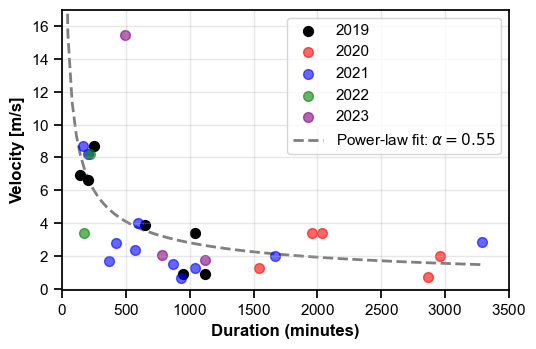

In [328]:
from scipy import optimize as opt

def pl(x, A, alpha):
    """Power-law function: A * x^(-alpha)"""
    return A * np.power(x, -alpha)

# Fit power-law to mins vs vels
try:
    popt_mins, pcov_mins = opt.curve_fit(pl, mins, vels, p0=[1, 0.5], 
                                         bounds=([0, 0.1], [np.inf, 3.0]), 
                                         maxfev=5000)
    A_mins, alpha_mins = popt_mins
    print(f"Mins vs Vels: A={A_mins:.4f}, alpha={alpha_mins:.4f}")
except Exception as e:
    print(f"Failed to fit mins: {e}")

# Plot the data and fit
fig, ax = plt.subplots()
# ax.scatter(mins, vels, alpha=0.6, s=50, label='Data')
ax.scatter(minutes, vel_2019, alpha=1, s=50, label="2019", color="black")
ax.scatter(minutes_20, vel_2020, alpha=0.6, s=50, label="2020", color="red")
ax.scatter(minutes_21, vel_2021, alpha=0.6, s=50, label="2021", color="blue")
ax.scatter(minutes_22, vel_2022, alpha=0.6, s=50, label="2022", color="green")
ax.scatter(minutes_23, vel_2023, alpha=0.6, s=50, label="2023", color="purple")

# Plot fit curve
x_fit = np.linspace(10, max(mins), 100)
try:
    y_fit = pl(x_fit, A_mins, alpha_mins)
    ax.plot(x_fit, y_fit, color='grey', linewidth=2, linestyle="--", 
            label=f'Power-law fit: $\\alpha={alpha_mins:.2f}$', zorder=0)
except:
    pass

ax.set_ylabel('Velocity [m/s]', fontweight='bold', fontsize=12)
ax.set_xlabel('Duration (minutes)', fontweight='bold', fontsize=12)
ax.set_ylim(-0.1, 17)
ax.set_xlim(-1, 3500)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("./output_images8/Velocity-vs-Duration.png", dpi=600)